# Complete information-pattern pipeline

This notebook runs the complete simulation pipeline for an ellipsoidal nanoparticle illuminated by a `HermiteGauss00` incident field.

The workflow is:

1. Define the nanoparticle geometry, material, and mass.
2. Define the `HermiteGauss00` incident field using the filling factor.
3. Compute librational information patterns around `x`, `y`, and `z`.
4. Compute center-of-mass information patterns along `x`, `y`, and `z`.
5. Evaluate the maximum detection efficiency for librational and COM motion.
6. Compute optical force and torque curves.
7. Estimate recoil force-noise, trap frequencies, and recoil heating rates.

## General imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

## Repository imports and default configuration

In [3]:
import info_patterns.parameters as params
import info_patterns.constants as const
import info_patterns.generate_nanoparticle as gen
import info_patterns.light_matter_interaction_simulation as lmi
import info_patterns.information_patterns_simulation as ips
import info_patterns.measurement_tools as mt
import info_patterns.plots as plots
plots.set_plot_style(usetex=params.DEFAULT_USETEX, font_family=params.DEFAULT_FONT_FAMILY, figsize=params.DEFAULT_FIGSIZE) # Apply the default plotting style used across the repository 

## Simulation parameters

In [4]:
# Far-field angular sampling parameters
farfield_params = params.FAST_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
r = farfield_params["r"]
field_index = farfield_params["field_index"]

# Simulator parameters
step_nm = params.ELLIPSOID_GEOMETRY_PARAMS["step_nm"]
disp_nm = params.DEFAULT_COM_DISPLACEMENT_NM
angle_deg = params.DEFAULT_LIBRATION_ANGLE_DEG
wavelength_nm = params.DEFAULT_WAVELENGTH_NM

# Focused beam parameters
gamma = params.DEFAULT_FILLING_FACTOR
optical_power_W = params.DEFAULT_OPTICAL_POWER_W
impedance_ohm = params.DEFAULT_FREE_SPACE_IMPEDANCE_OHM
hermite_params = params.DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS.copy()

hermite_params["w0"] = lmi.w0_from_filling_factor(gamma=gamma, NA=hermite_params["NA"], f_mm=hermite_params["f"])
hermite_amplitude = lmi.hermite_gauss00_power_amplitude_factor(optical_power_W=optical_power_W, w0_mm=hermite_params["w0"], impedance_ohm=impedance_ohm)

# HermiteGauss00 requires exactly one of theta or polarization_state.
# Use polarization_state to include the physical amplitude.
hermite_params["theta"] = None
hermite_params["polarization_state"] = (hermite_amplitude, 0.0, 0.0, 0.0)

print("Incident field: HermiteGauss00")
print("gamma =", gamma)
print("NA =", hermite_params["NA"])
print("f =", hermite_params["f"], "mm")
print("w0 =", hermite_params["w0"], "mm")
print("optical power =", optical_power_W, "W")
print("amplitude factor =", hermite_amplitude)
print("normalize =", hermite_params["normalize"])
print("theta =", hermite_params["theta"])
print("polarization_state =", hermite_params["polarization_state"])

Incident field: HermiteGauss00
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm
optical power = 0.001 W
amplitude factor = 10.000117794776598
normalize = False
theta = None
polarization_state = (10.000117794776598, 0.0, 0.0, 0.0)


## Nanoparticle geometry, material, and mass

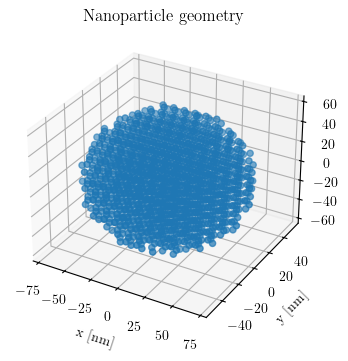

Geometry shape: (1383, 3)
Geometry center: [ 0.0000000e+00 -1.5101567e-06  4.1539652e-06]
Material: <pyGDM2.materials.sio2 object at 0x10cd1a990>
Mass: 1.935221e-18 kg


In [5]:
geometry = gen.nanoparticle_geometry(**params.ELLIPSOID_GEOMETRY_PARAMS) # Generate the discretized nanoparticle geometry 
material = gen.nanoparticle_material(params.DEFAULT_MATERIAL_NAME, **params.DEFAULT_MATERIAL_KWARGS) # Load the optical material model used by pyGDM
mass = gen.nanoparticle_mass(geometry=geometry, particle_type=params.ELLIPSOID_GEOMETRY_PARAMS["particle_type"], step_nm=step_nm, material_name=params.DEFAULT_MATERIAL_NAME, 
                         mesh=params.ELLIPSOID_GEOMETRY_PARAMS["mesh"], method="analytic", R1=params.ELLIPSOID_GEOMETRY_PARAMS["R1"], R2=params.ELLIPSOID_GEOMETRY_PARAMS["R2"], R3=params.ELLIPSOID_GEOMETRY_PARAMS["R3"])

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Nanoparticle geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)
print(f"Mass: {mass:.6e} kg")

## Hermite-Gauss incident field and electromagnetic propagator

In [6]:
efield = lmi.incident_field(**hermite_params)
dyads = lmi.field_propagation(**params.DEFAULT_DYADS_PARAMS)

## Libration around x

In [7]:
E_lib_plus_x, E_lib_minus_x, dE_lib_x = lmi.librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_x_total, I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez = ips.info_patterns_from_scattered_field(dE=dE_lib_x, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 2001.3ms, inv.: 915.6ms, repropa.: 5522.4ms (1 field configs), tot: 8439.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 114.8ms, inv.: 949.5ms, repropa.: 5807.7ms (1 field configs), tot: 6872.2ms


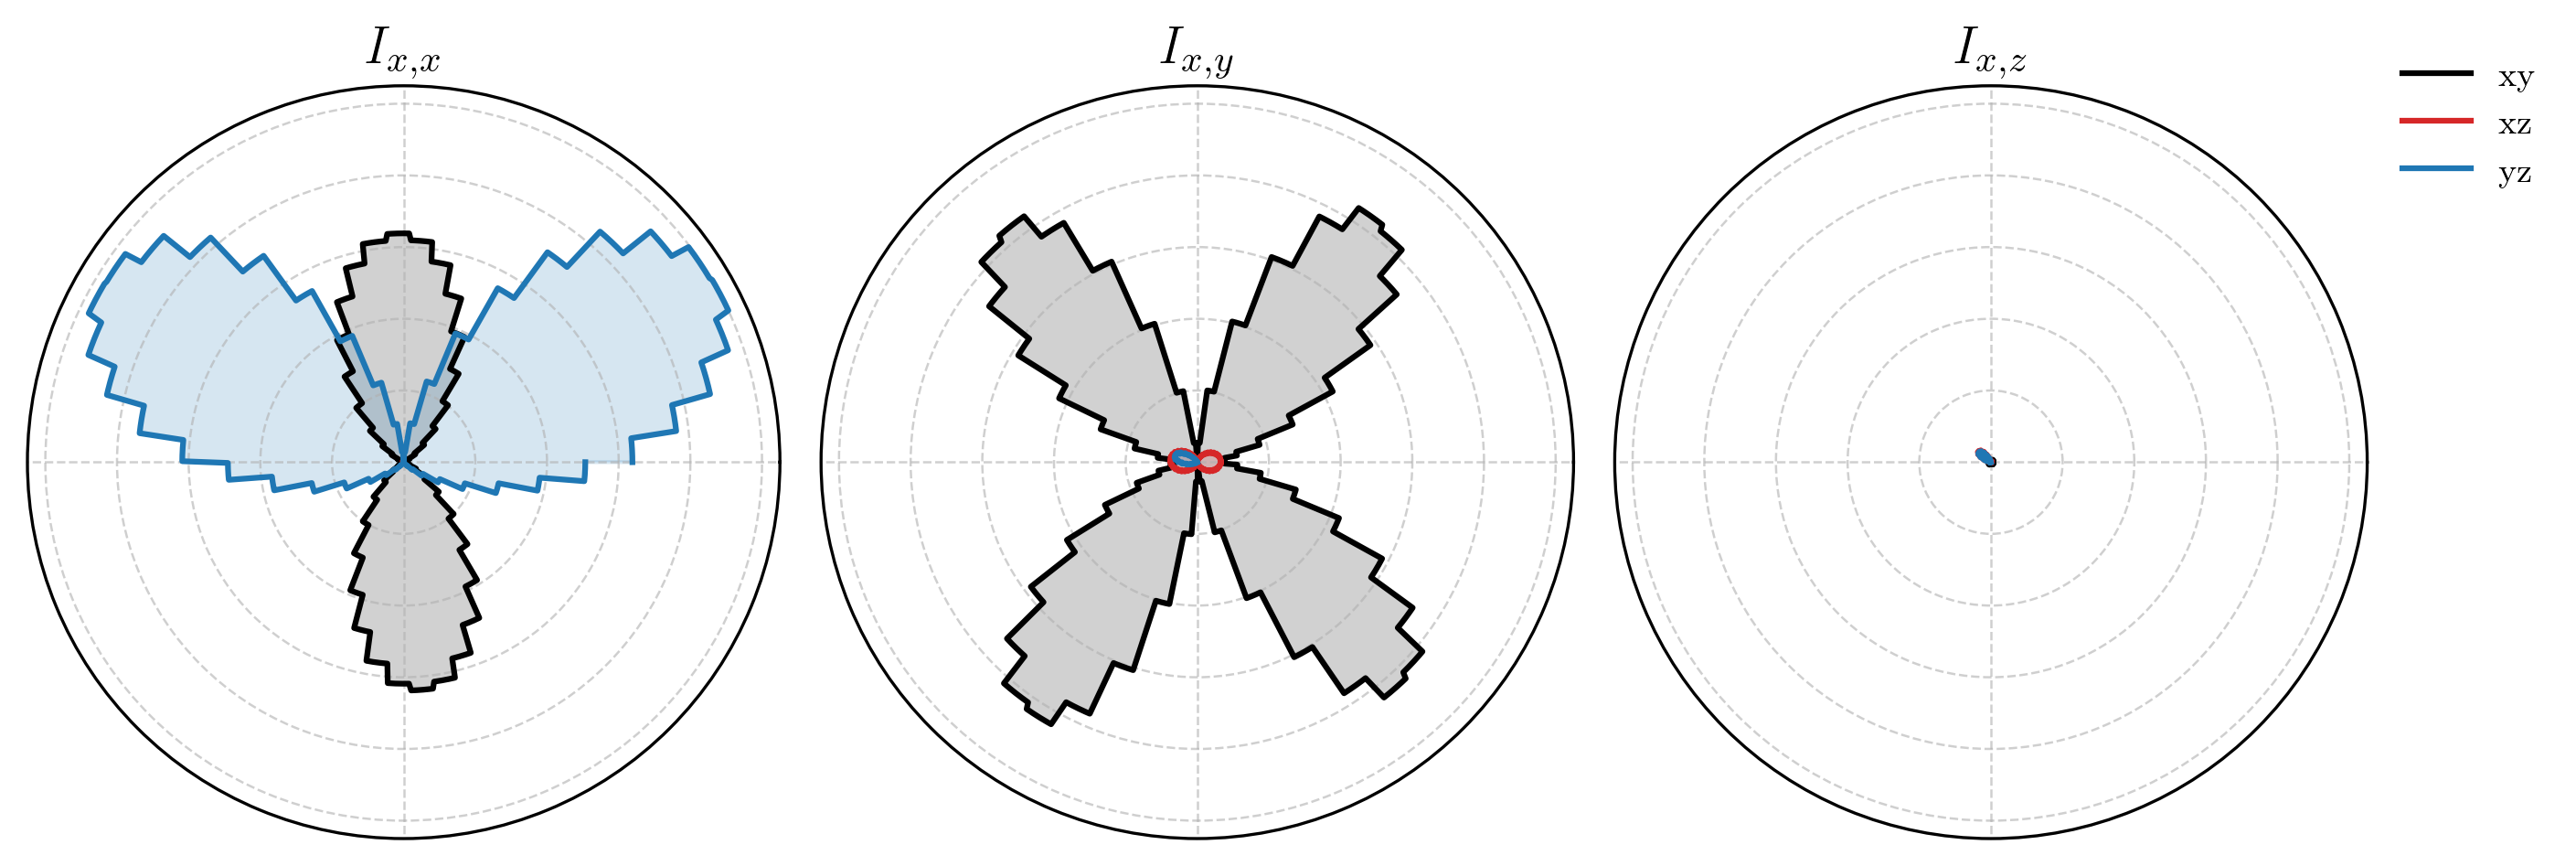

In [8]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"])

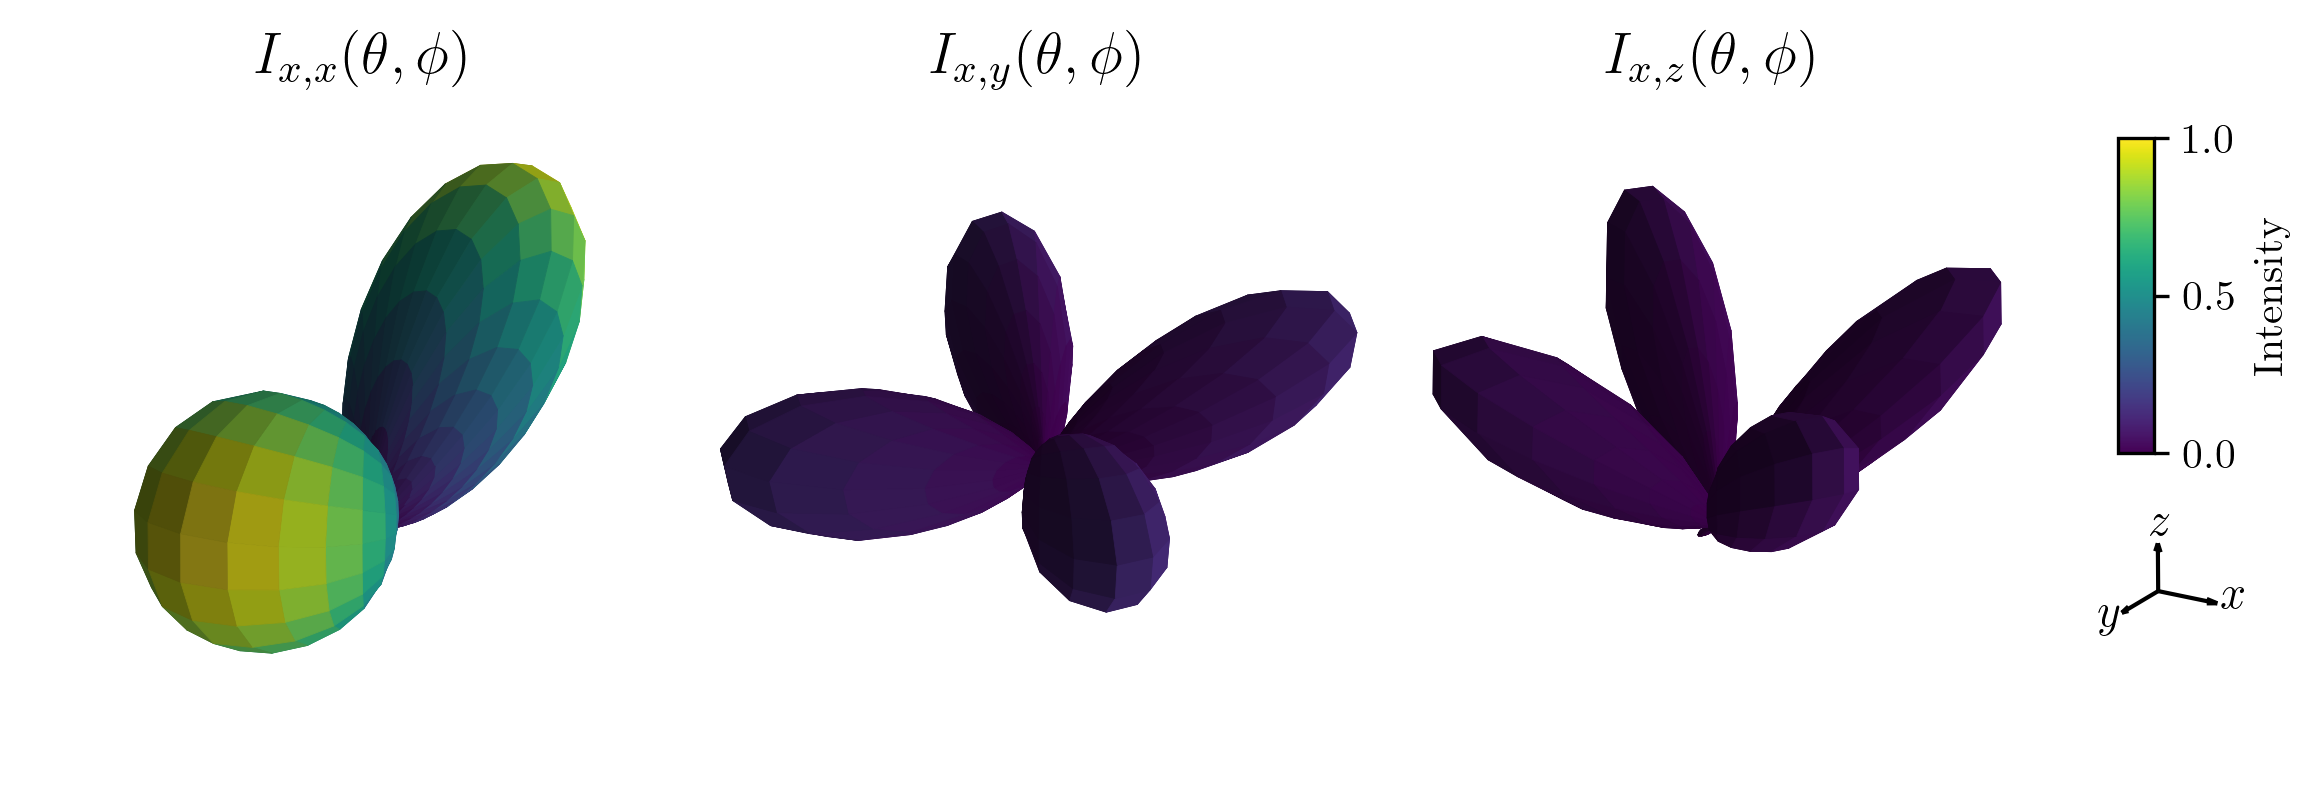

In [16]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], scale_list=[0.22, 0.3, 0.38])

## Libration around y

In [10]:
E_lib_plus_y, E_lib_minus_y, dE_lib_y = lmi.librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_y_total, I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez = ips.info_patterns_from_scattered_field(dE=dE_lib_y, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 154.8ms, inv.: 1231.1ms, repropa.: 5704.0ms (1 field configs), tot: 7091.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 99.3ms, inv.: 977.9ms, repropa.: 5450.7ms (1 field configs), tot: 6528.1ms


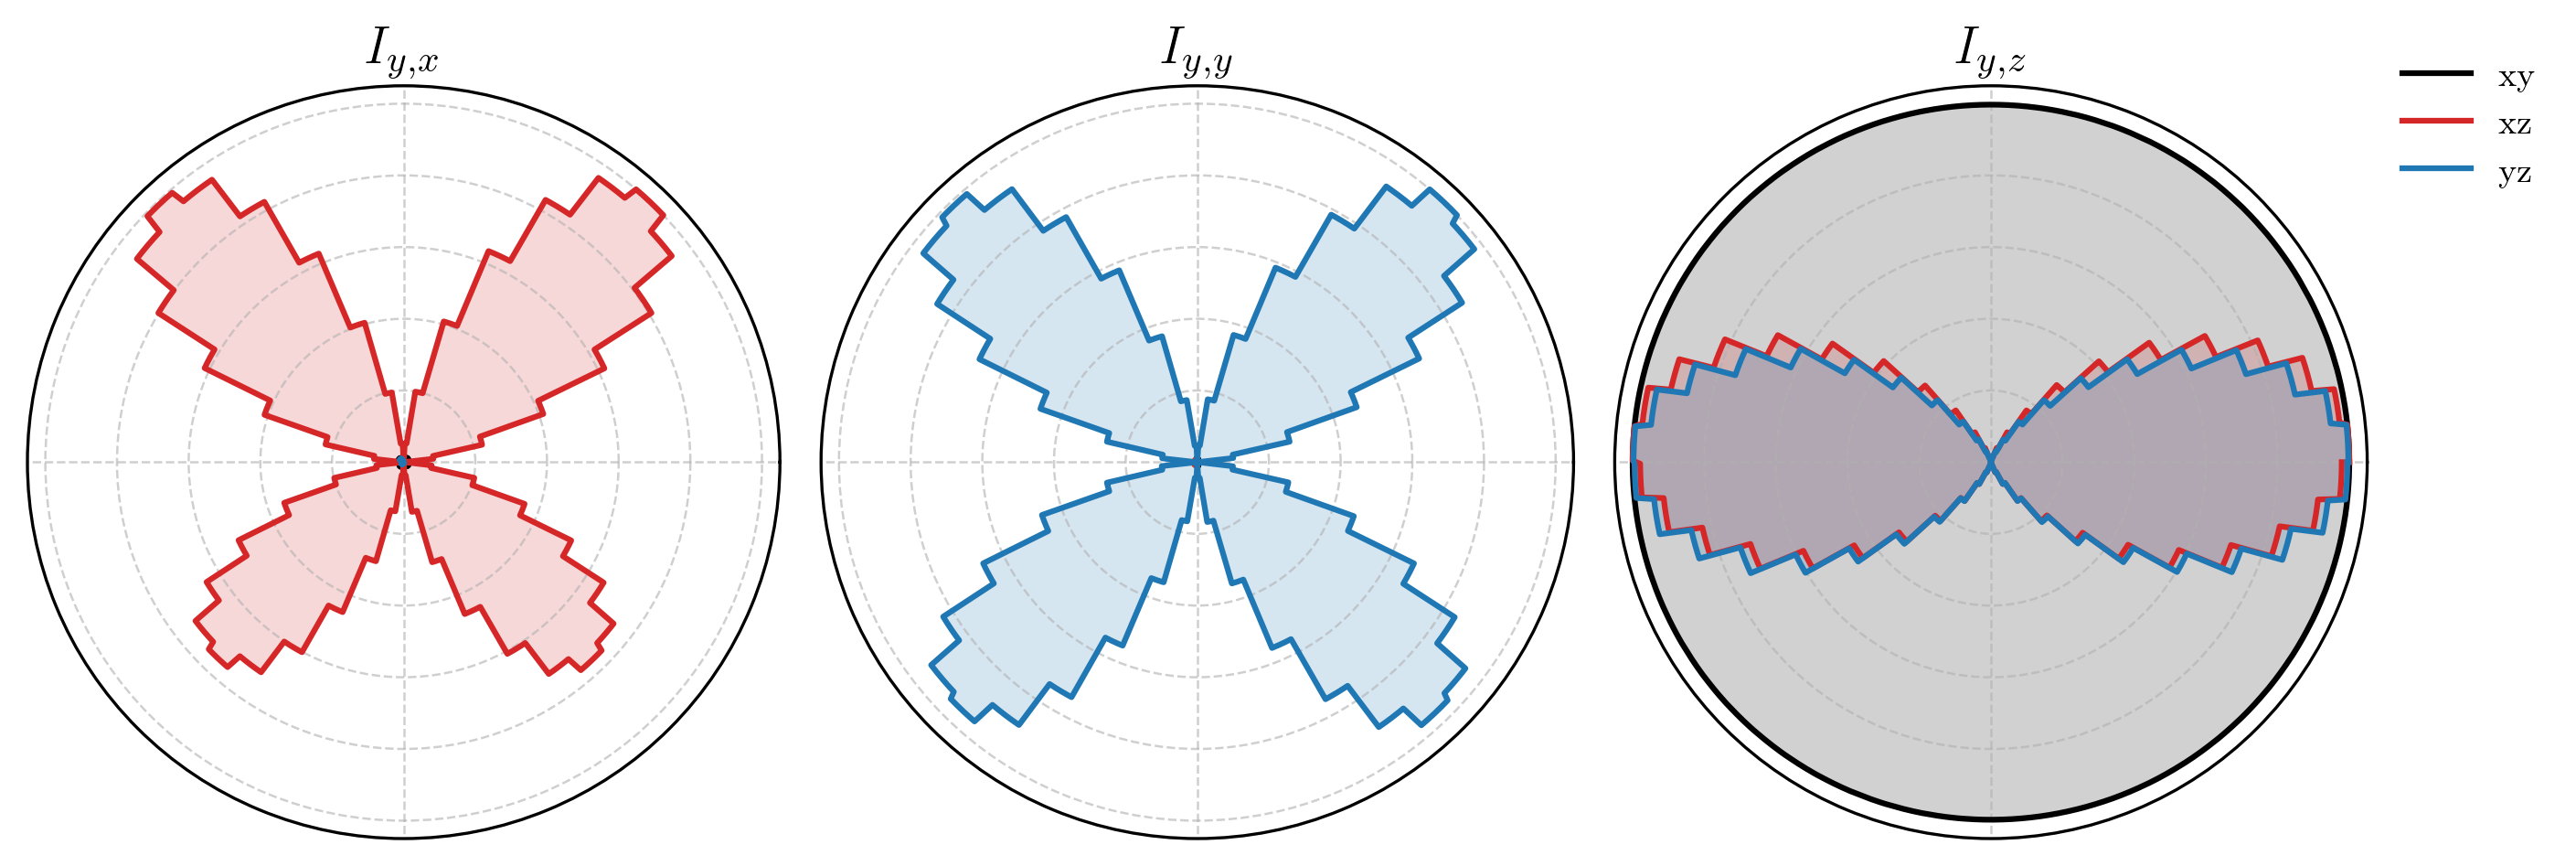

In [11]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"])

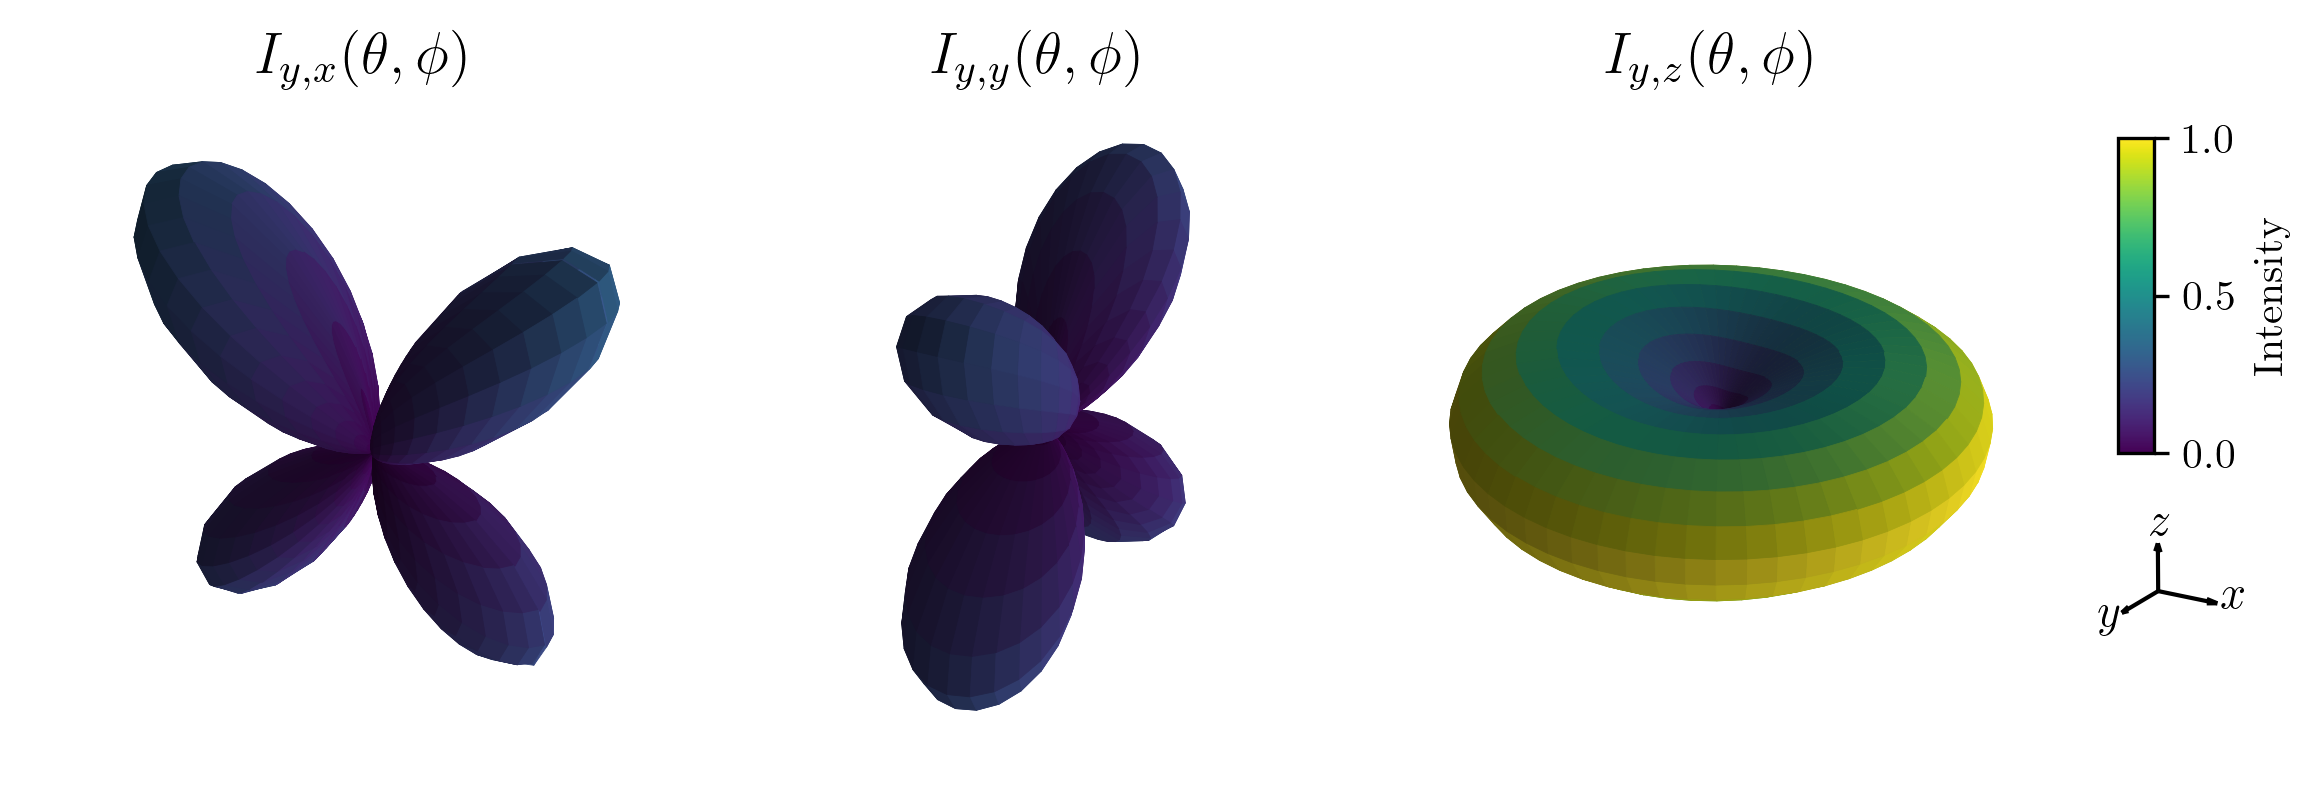

In [18]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], scale_list=[0.34, 0.38, 0.32])

## Libration around z

In [19]:
E_lib_plus_z, E_lib_minus_z, dE_lib_z = lmi.librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_z_total, I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez = ips.info_patterns_from_scattered_field(dE=dE_lib_z, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 134.9ms, inv.: 996.9ms, repropa.: 5200.2ms (1 field configs), tot: 6332.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 97.0ms, inv.: 953.4ms, repropa.: 5715.0ms (1 field configs), tot: 6765.6ms


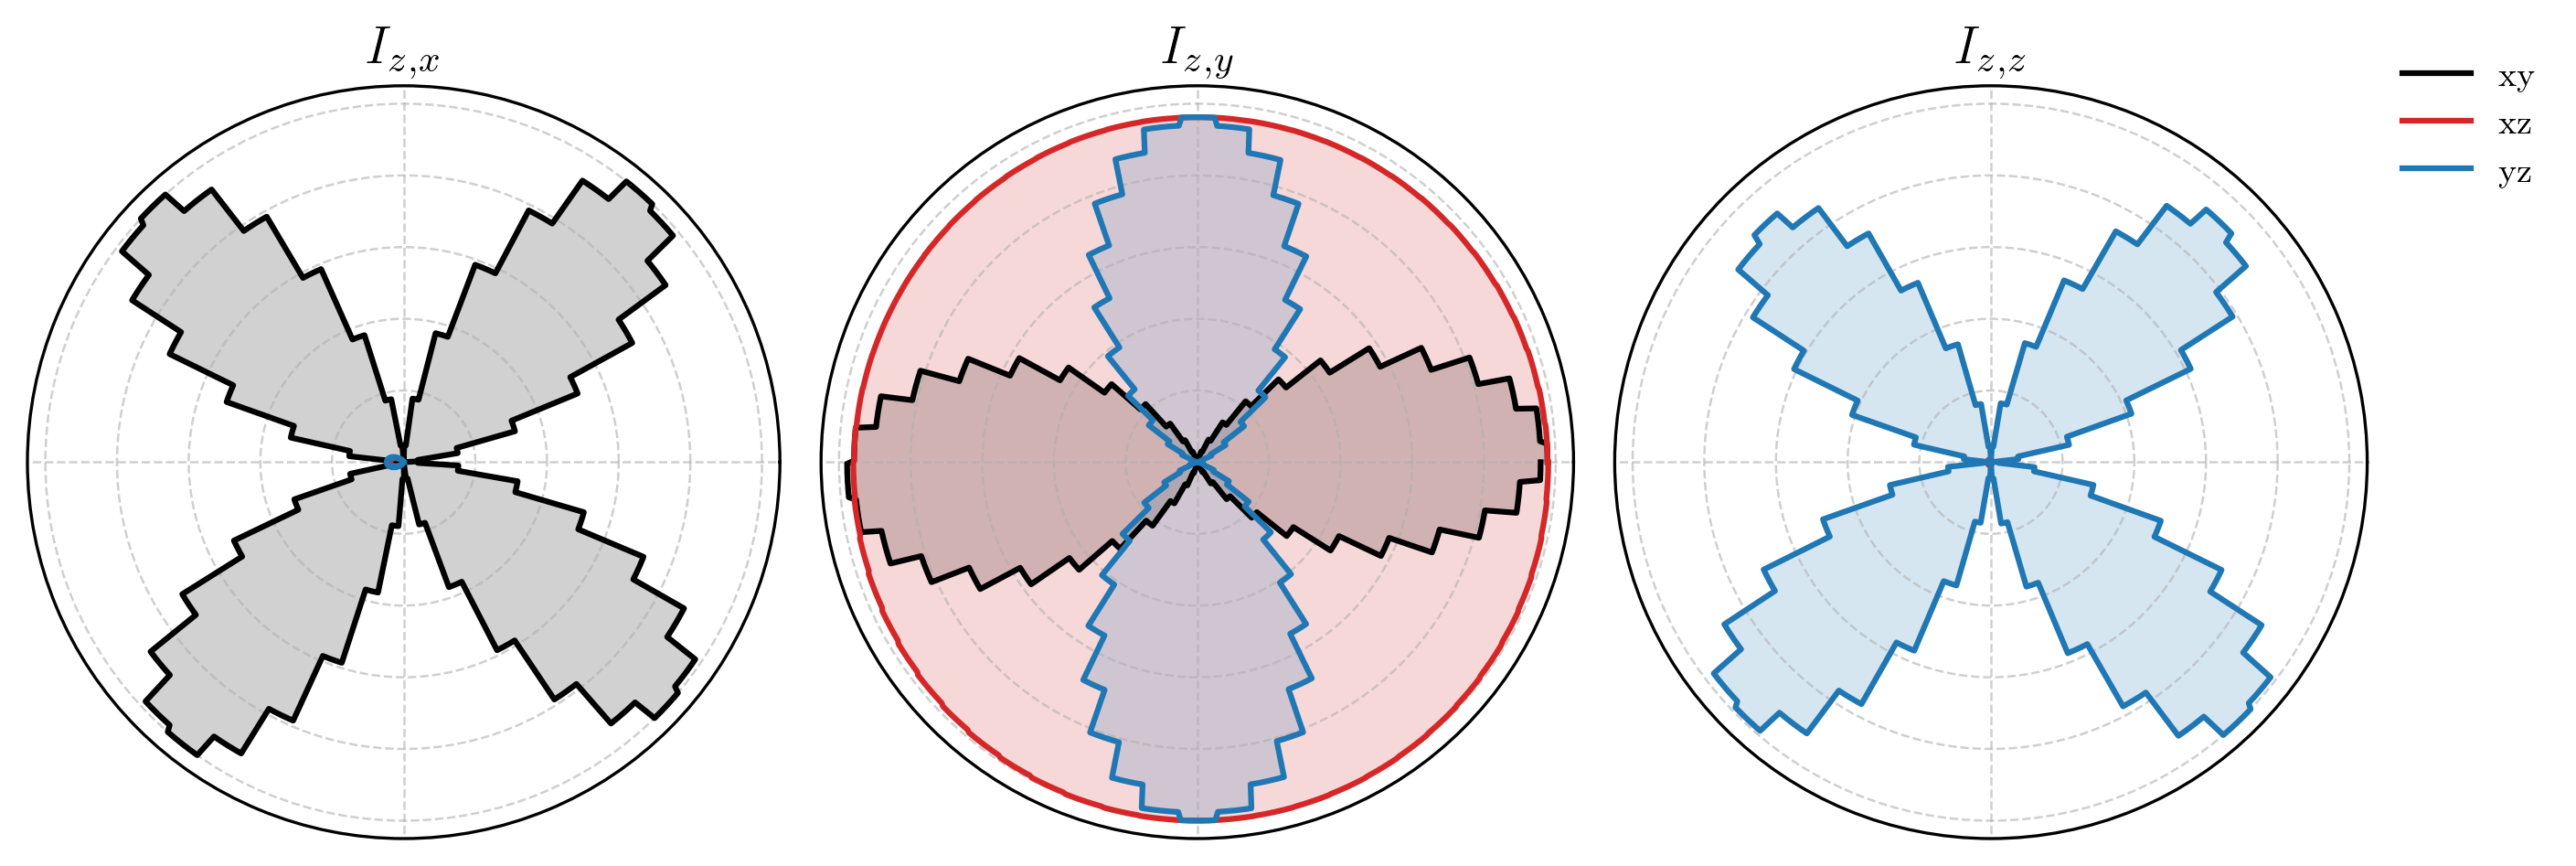

In [20]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"])

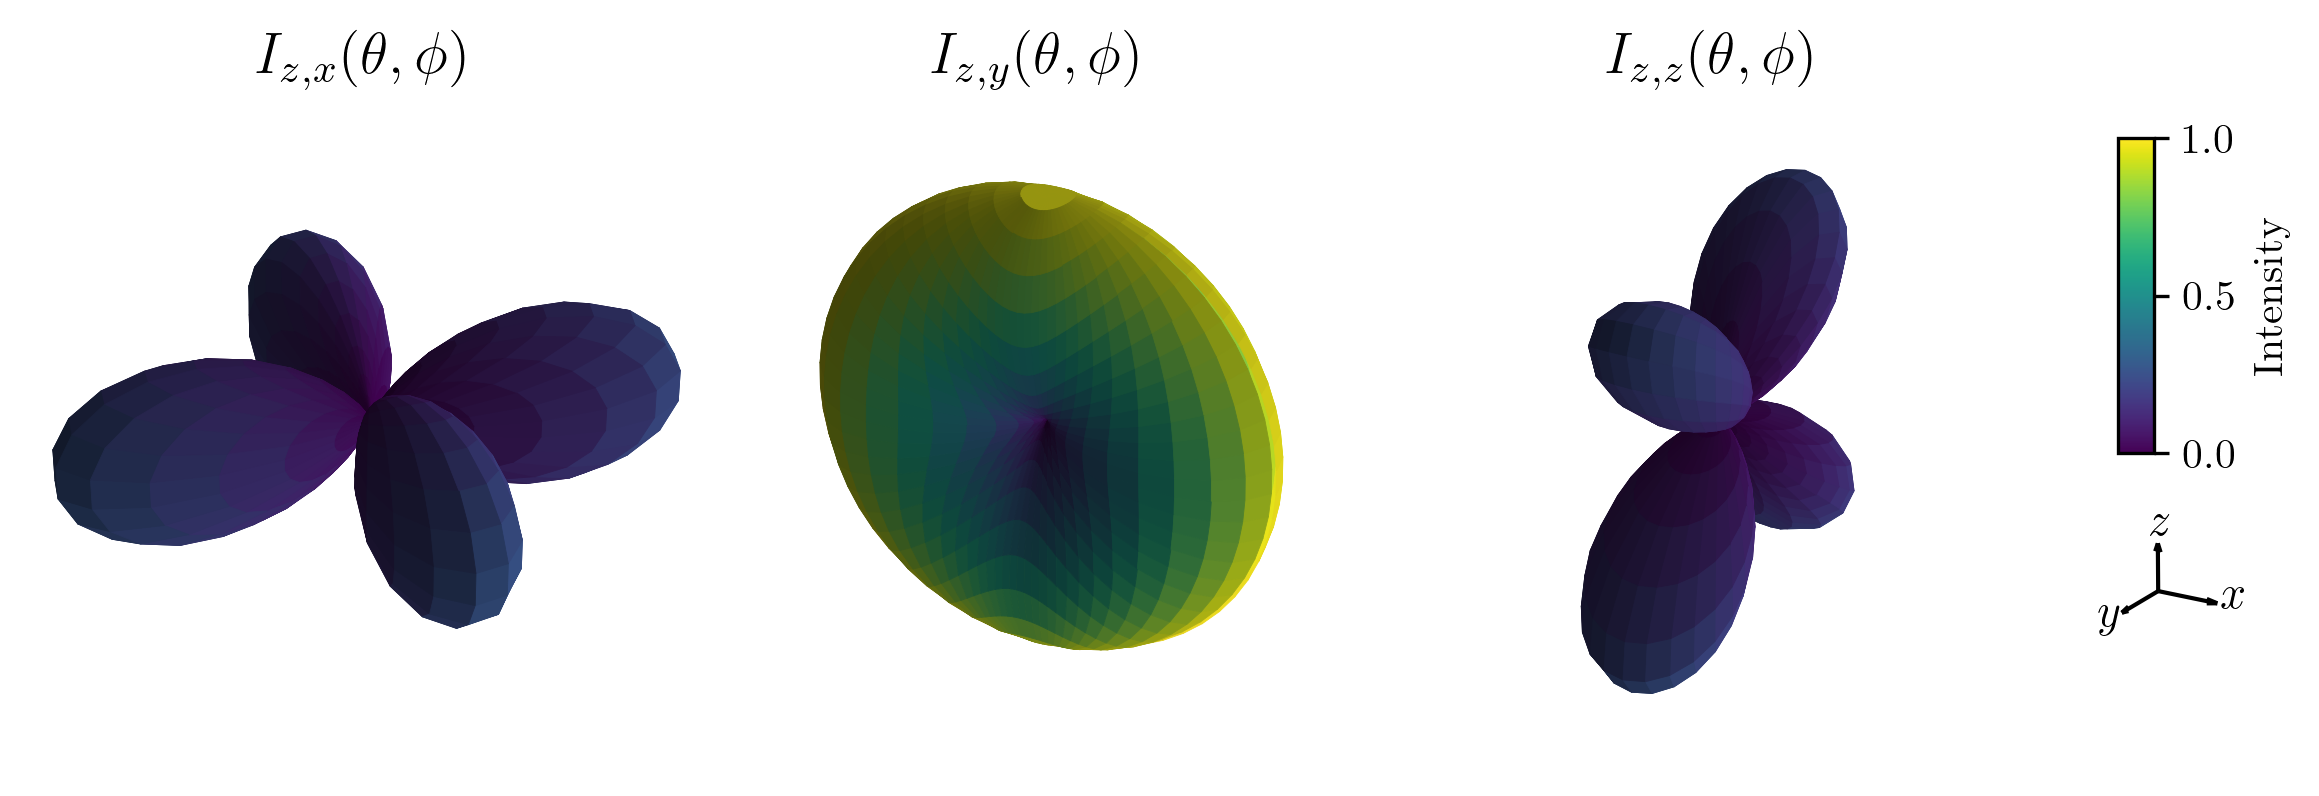

In [21]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], scale_list=[0.34, 0.34, 0.4])

## Total librational information patterns

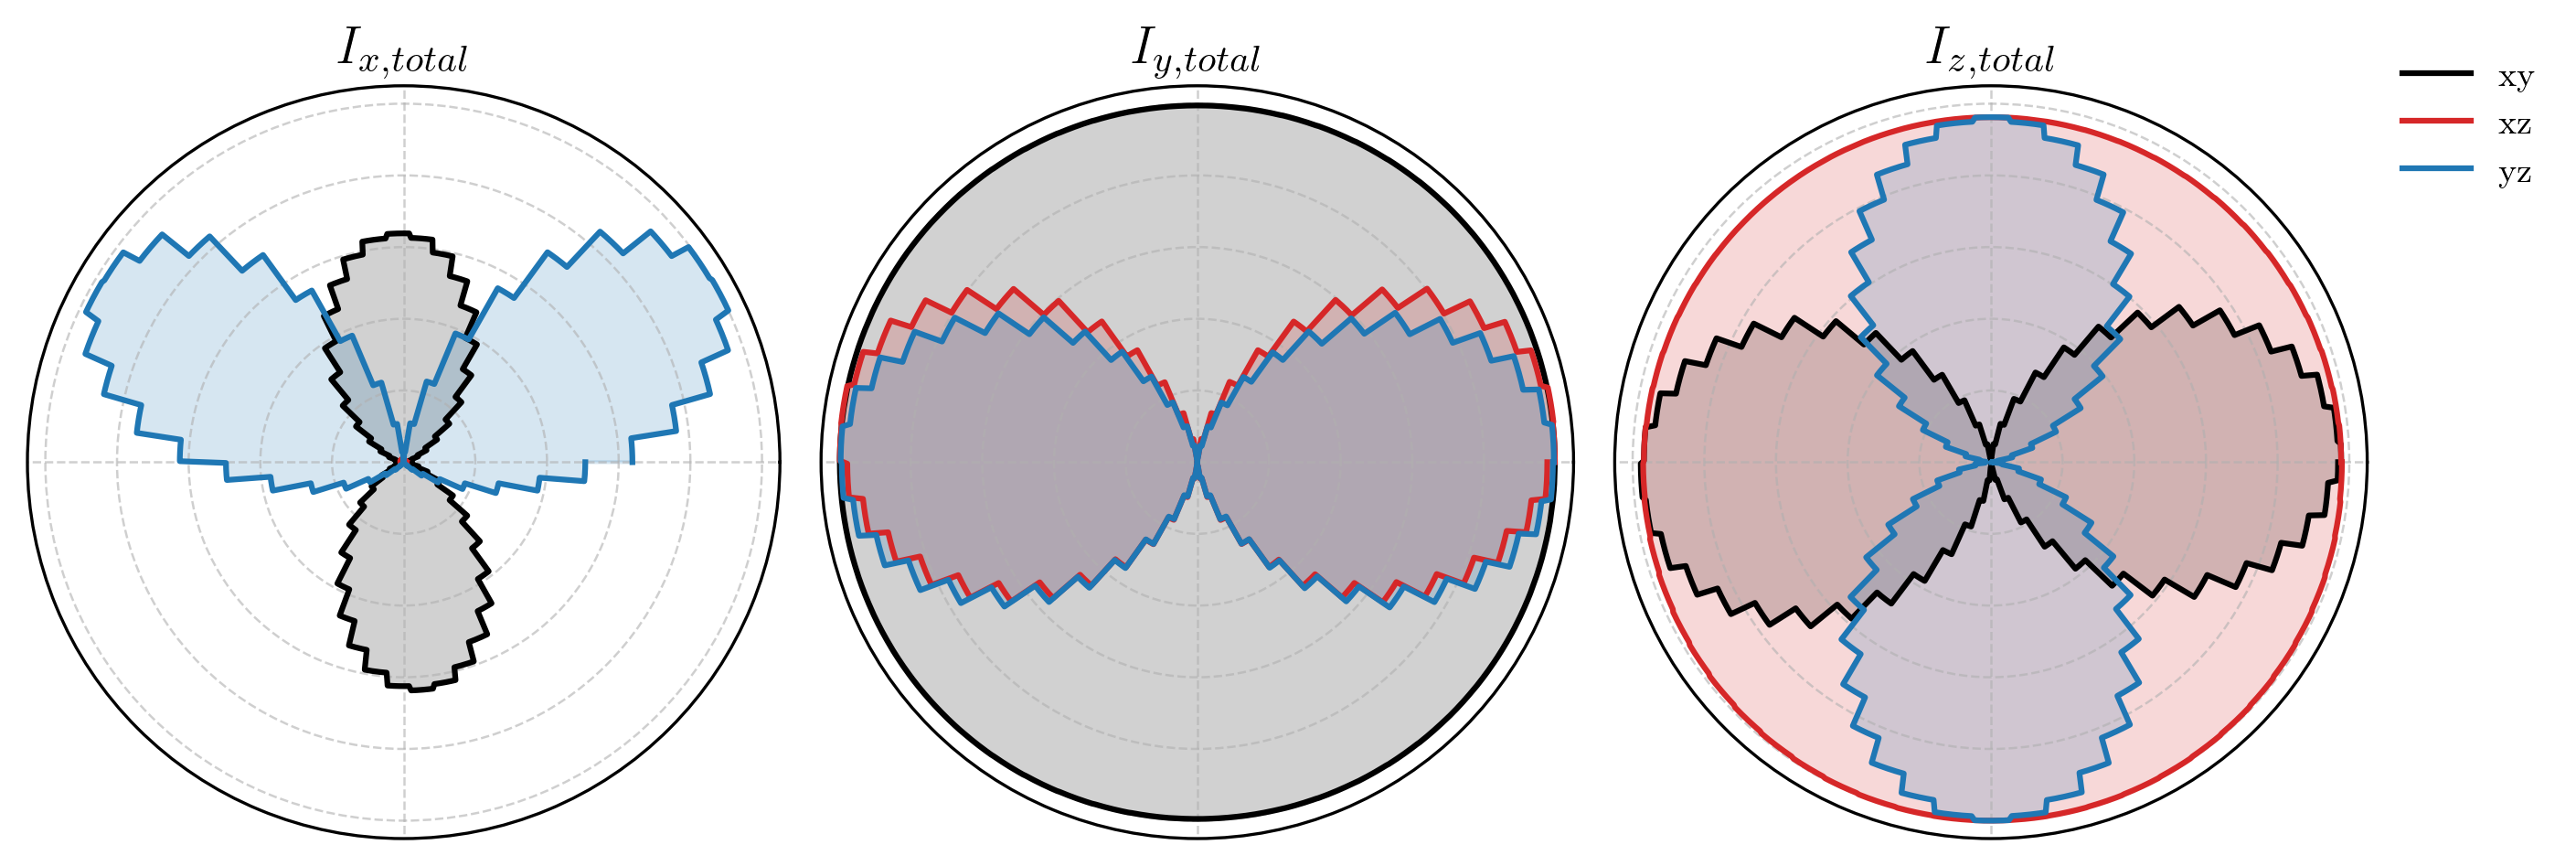

In [22]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"])

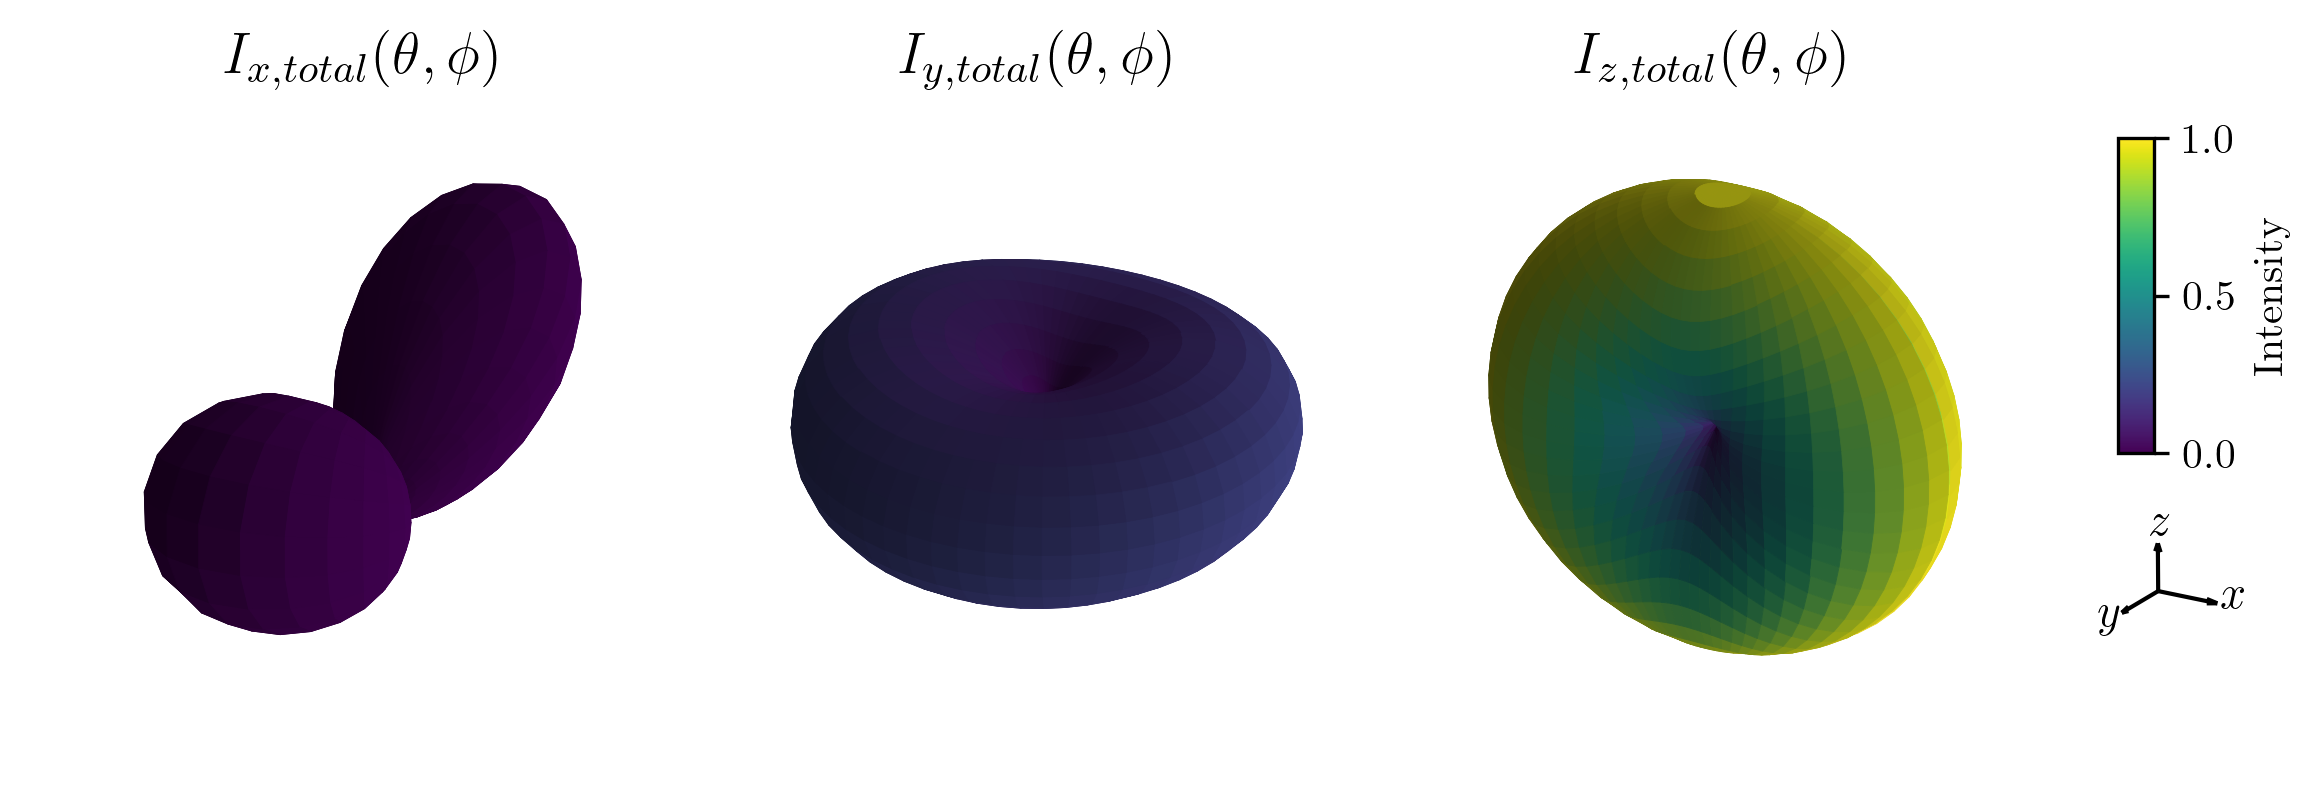

In [24]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], scale_list=[0.24, 0.34, 0.34])

## COM displacement along x

In [25]:
E_com_plus_x, E_com_minus_x, dE_com_x = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, disp_nm=disp_nm, 
                                                               Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_com_x_total, I_com_x_Ex, I_com_x_Ey, I_com_x_Ez = ips.info_patterns_from_scattered_field(dE=dE_com_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 118.0ms, inv.: 904.4ms, repropa.: 5081.5ms (1 field configs), tot: 6104.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 113.3ms, inv.: 890.3ms, repropa.: 5032.8ms (1 field configs), tot: 6036.6ms


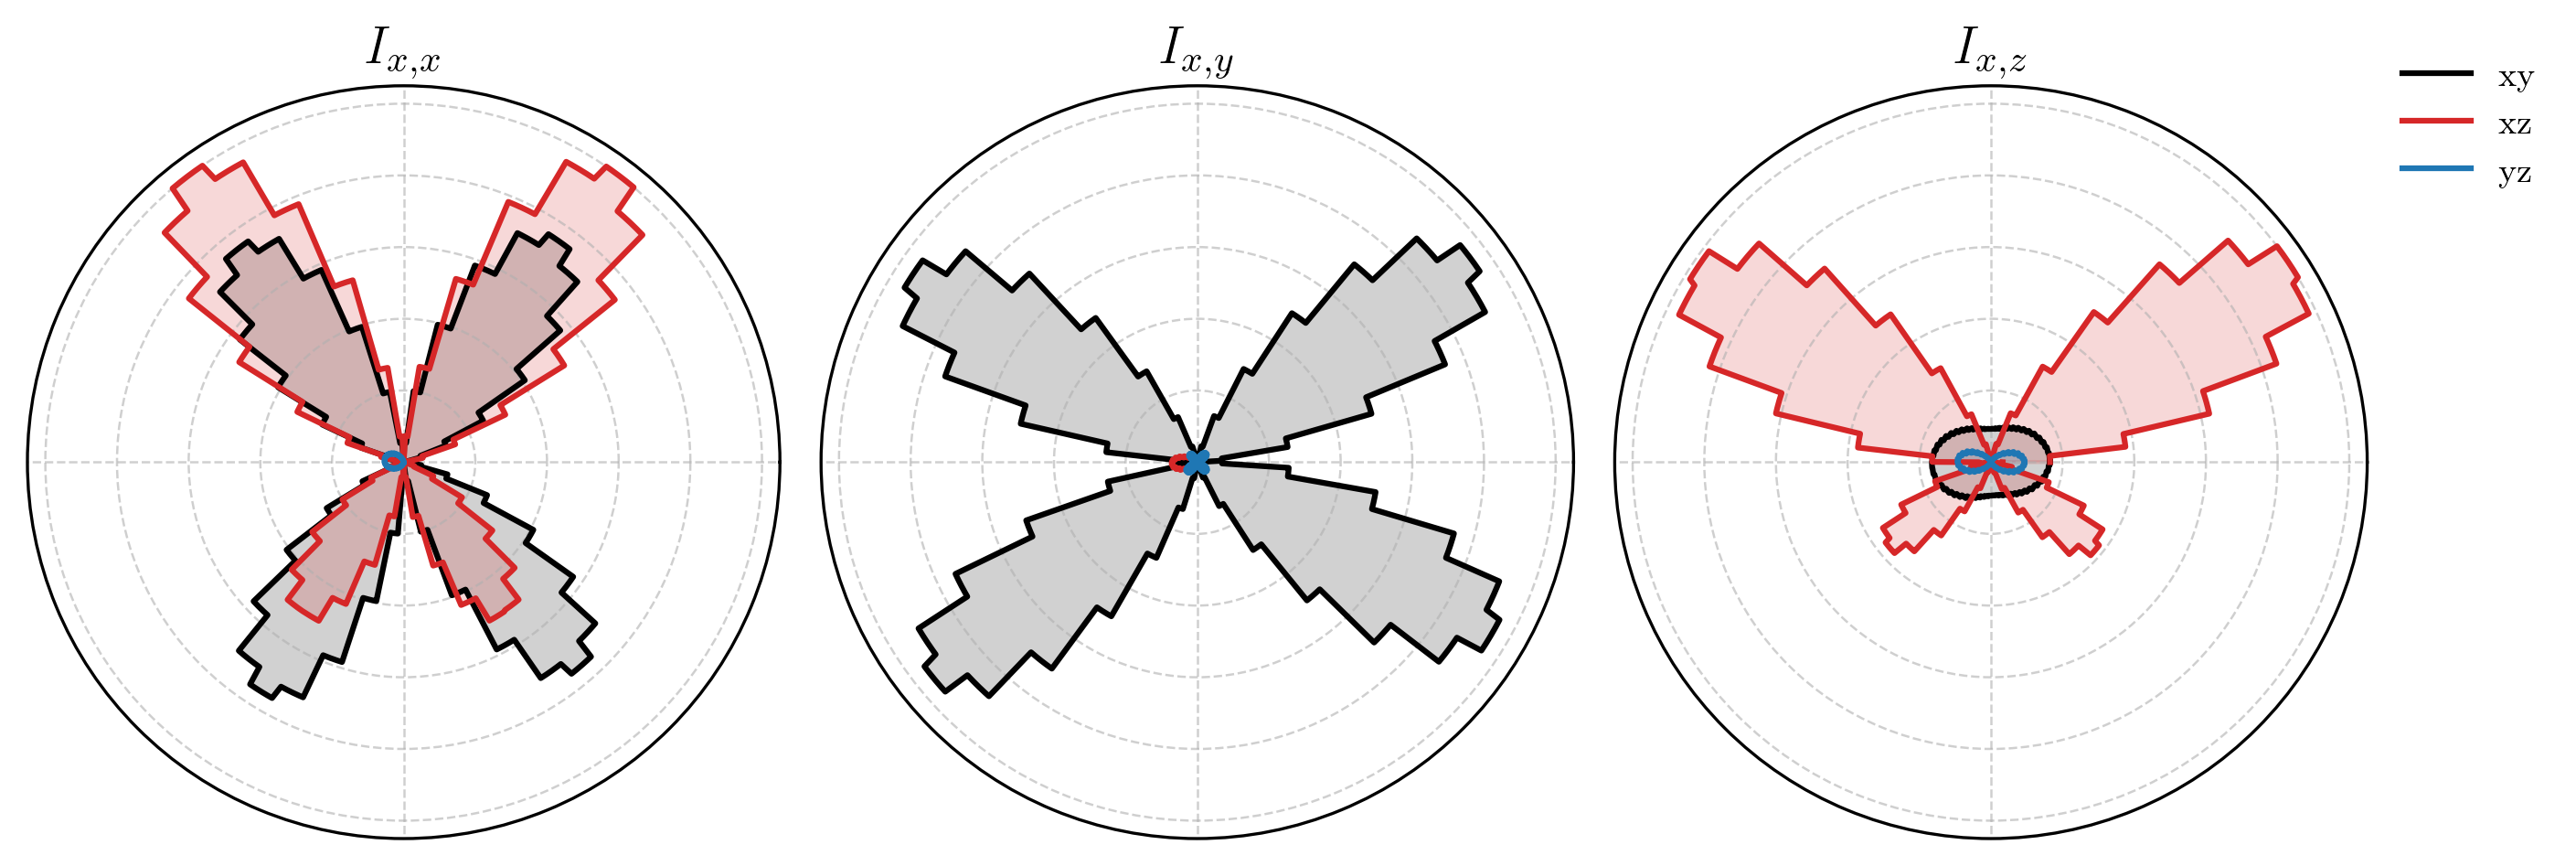

In [26]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_Ex, I_com_x_Ey, I_com_x_Ez], labels=["x,x", "x,y", "x,z"])

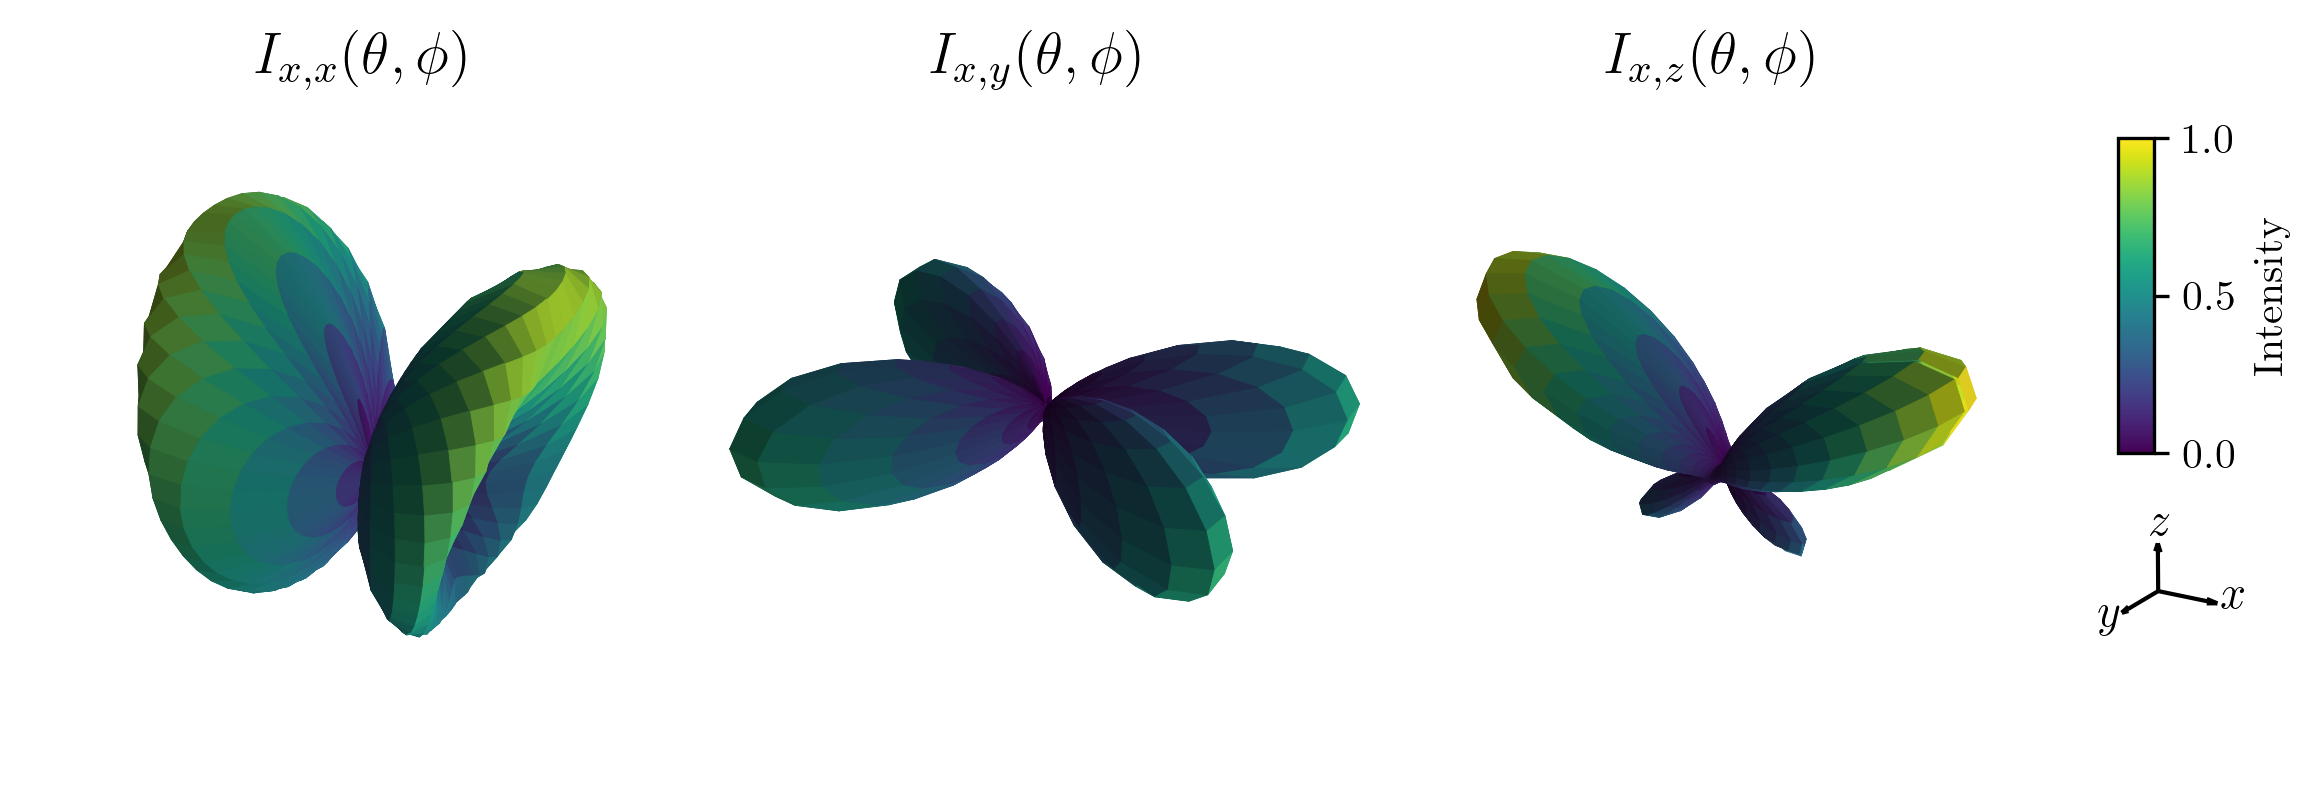

In [27]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_Ex, I_com_x_Ey, I_com_x_Ez], labels=["x,x", "x,y", "x,z"], scale_list=[0.42, 0.32, 0.32])

## COM displacement along y

In [28]:
E_com_plus_y, E_com_minus_y, dE_com_y = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, disp_nm=disp_nm, Nteta=Nteta, 
                                                               Nphi=Nphi, field_index=field_index, r=r)
I_com_y_total, I_com_y_Ex, I_com_y_Ey, I_com_y_Ez = ips.info_patterns_from_scattered_field(dE=dE_com_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 145.8ms, inv.: 893.6ms, repropa.: 5390.4ms (1 field configs), tot: 6429.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 104.7ms, inv.: 1028.0ms, repropa.: 4883.7ms (1 field configs), tot: 6016.5ms


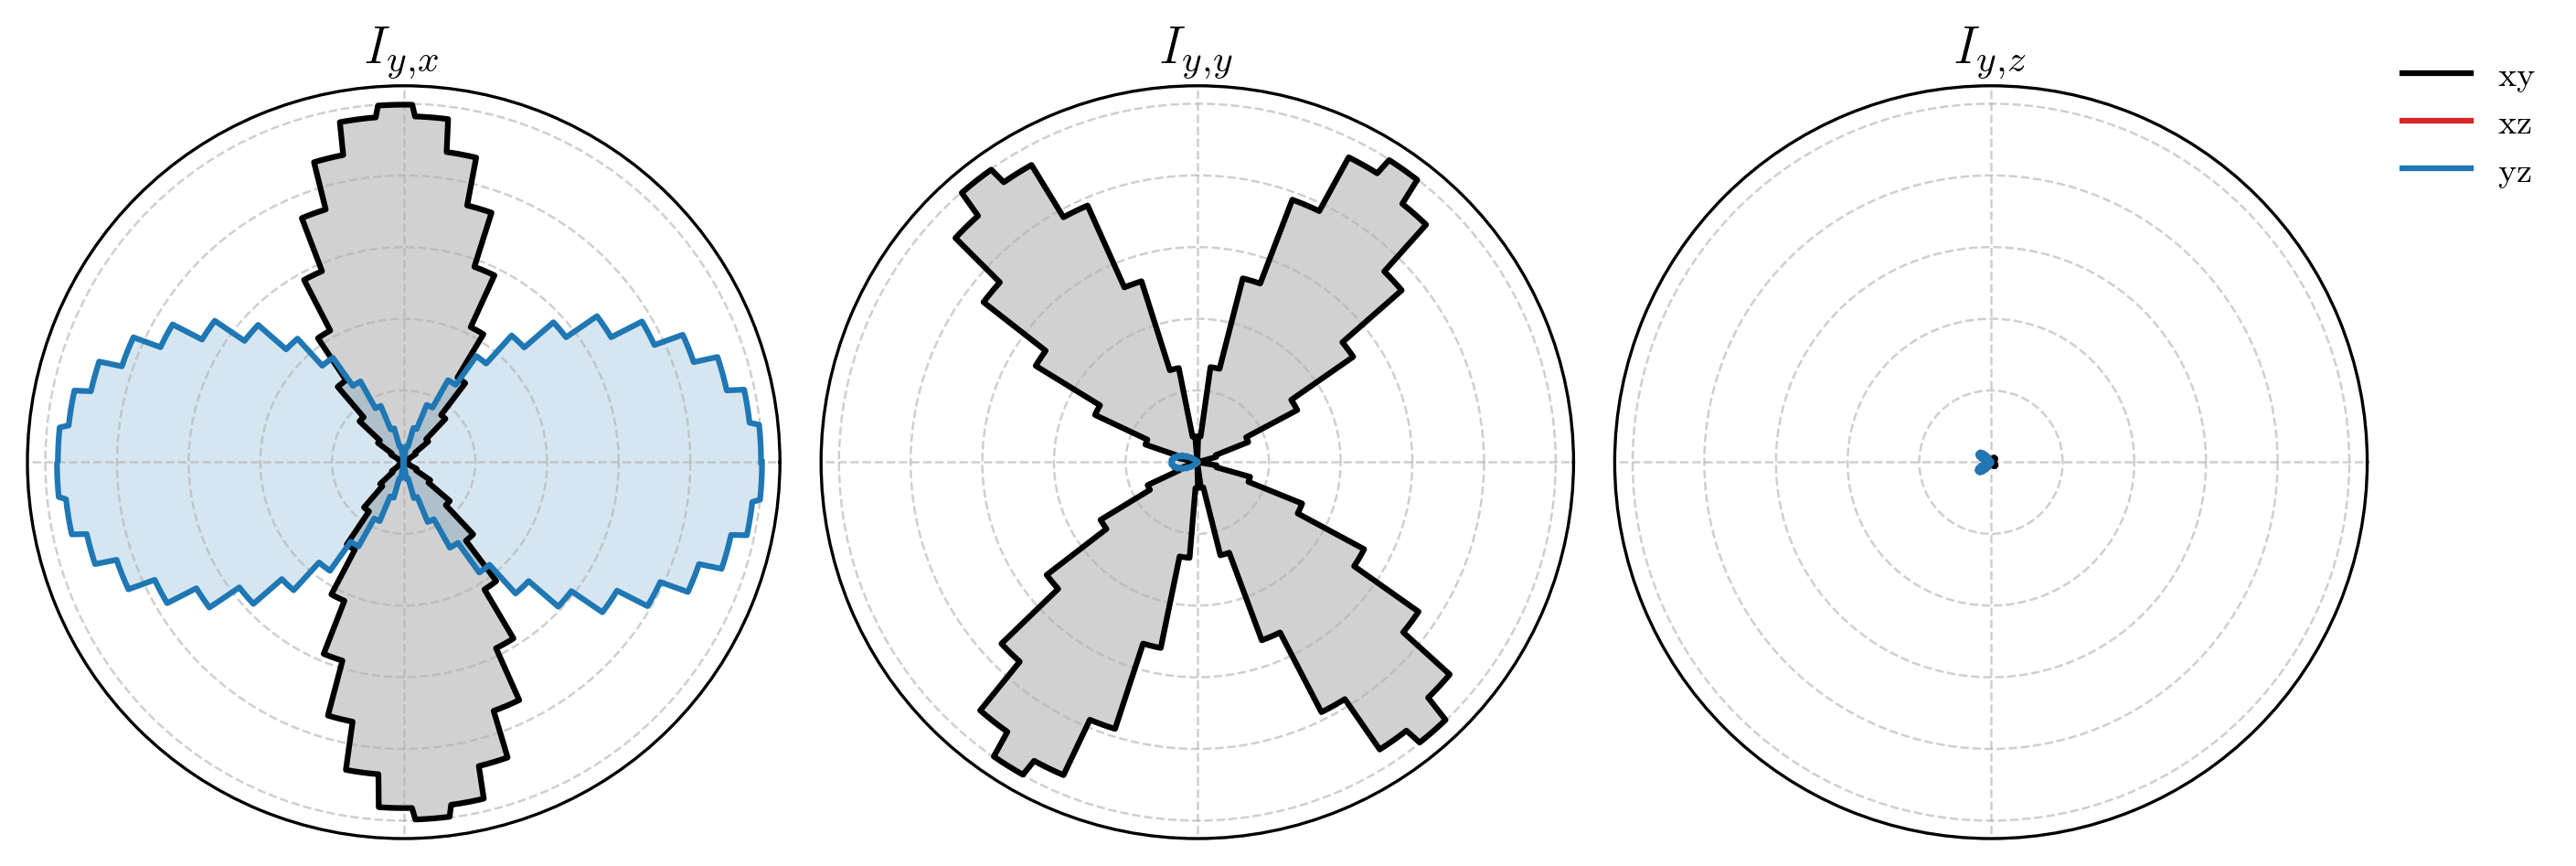

In [29]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_y_Ex, I_com_y_Ey, I_com_y_Ez], labels=["y,x", "y,y", "y,z"])

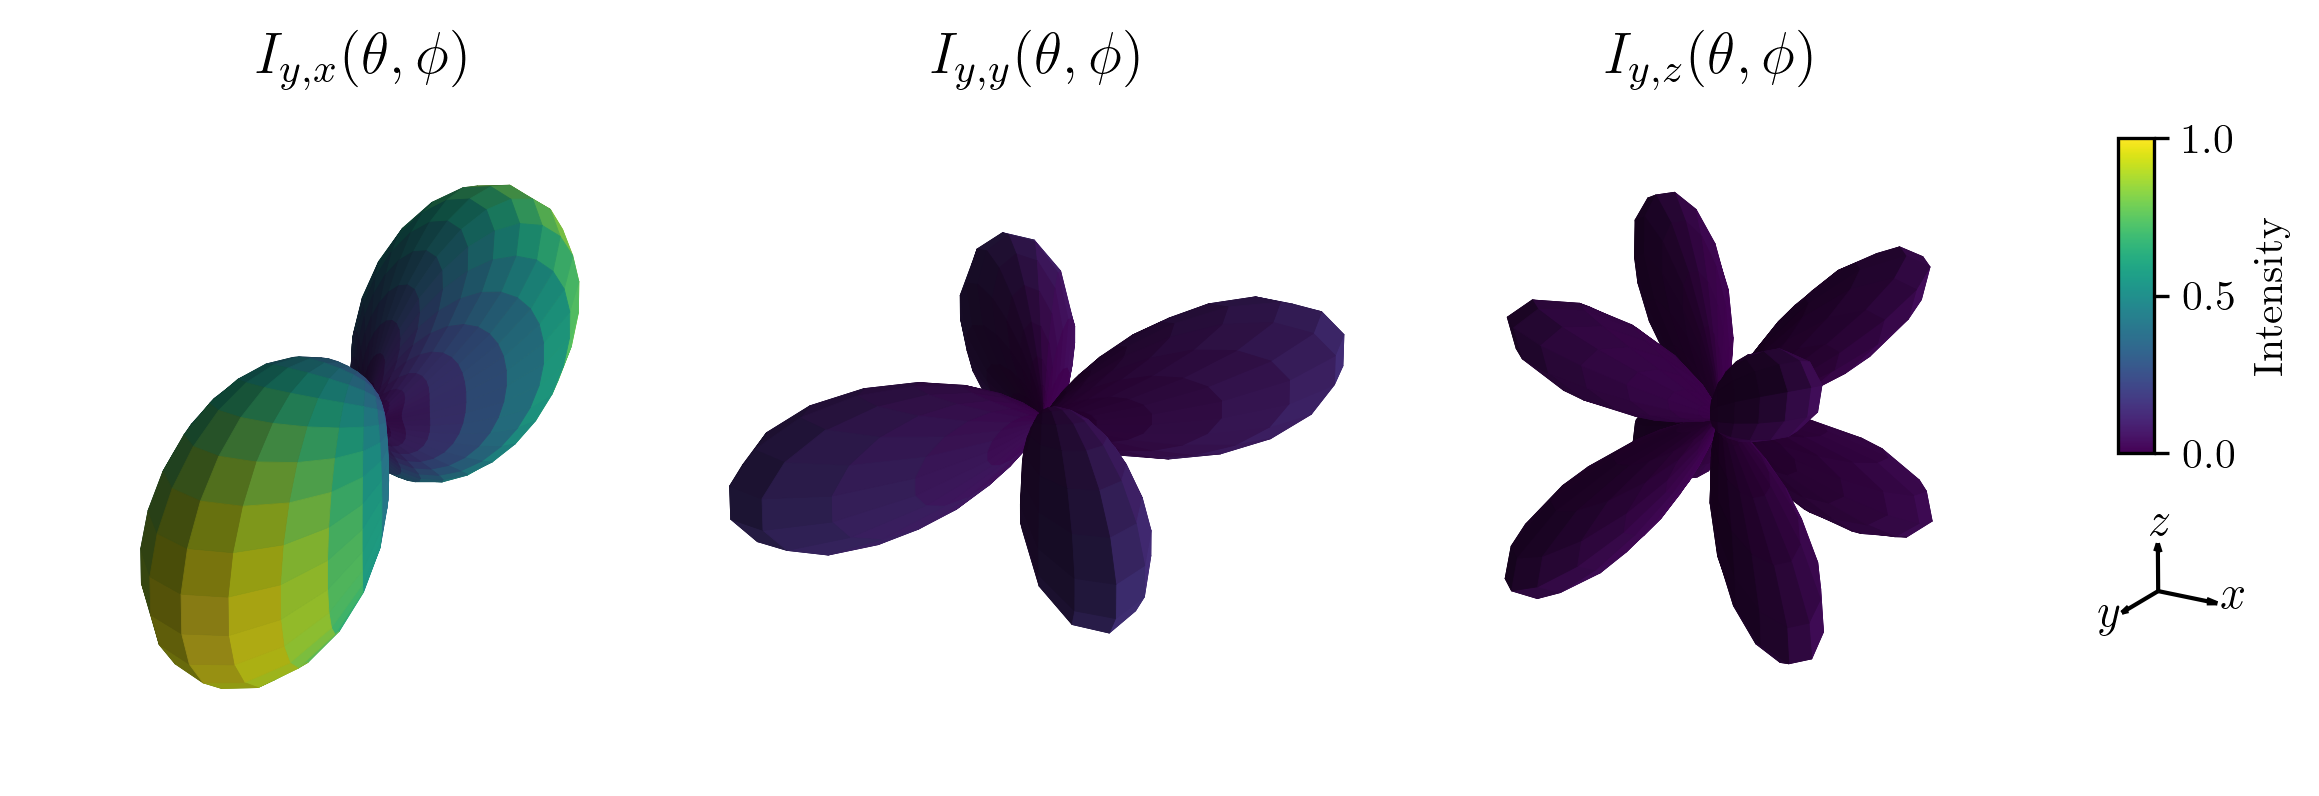

In [30]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_y_Ex, I_com_y_Ey, I_com_y_Ez], labels=["y,x", "y,y", "y,z"], scale_list=[0.22, 0.30, 0.49])

## COM displacement along z

In [31]:
E_com_plus_z, E_com_minus_z, dE_com_z = lmi.com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, disp_nm=disp_nm, Nteta=Nteta, 
                                                               Nphi=Nphi, field_index=field_index, r=r)
I_com_z_total, I_com_z_Ex, I_com_z_Ey, I_com_z_Ez = ips.info_patterns_from_scattered_field(dE=dE_com_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 140.5ms, inv.: 960.0ms, repropa.: 5410.0ms (1 field configs), tot: 6510.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 93.6ms, inv.: 975.9ms, repropa.: 4830.4ms (1 field configs), tot: 5900.0ms


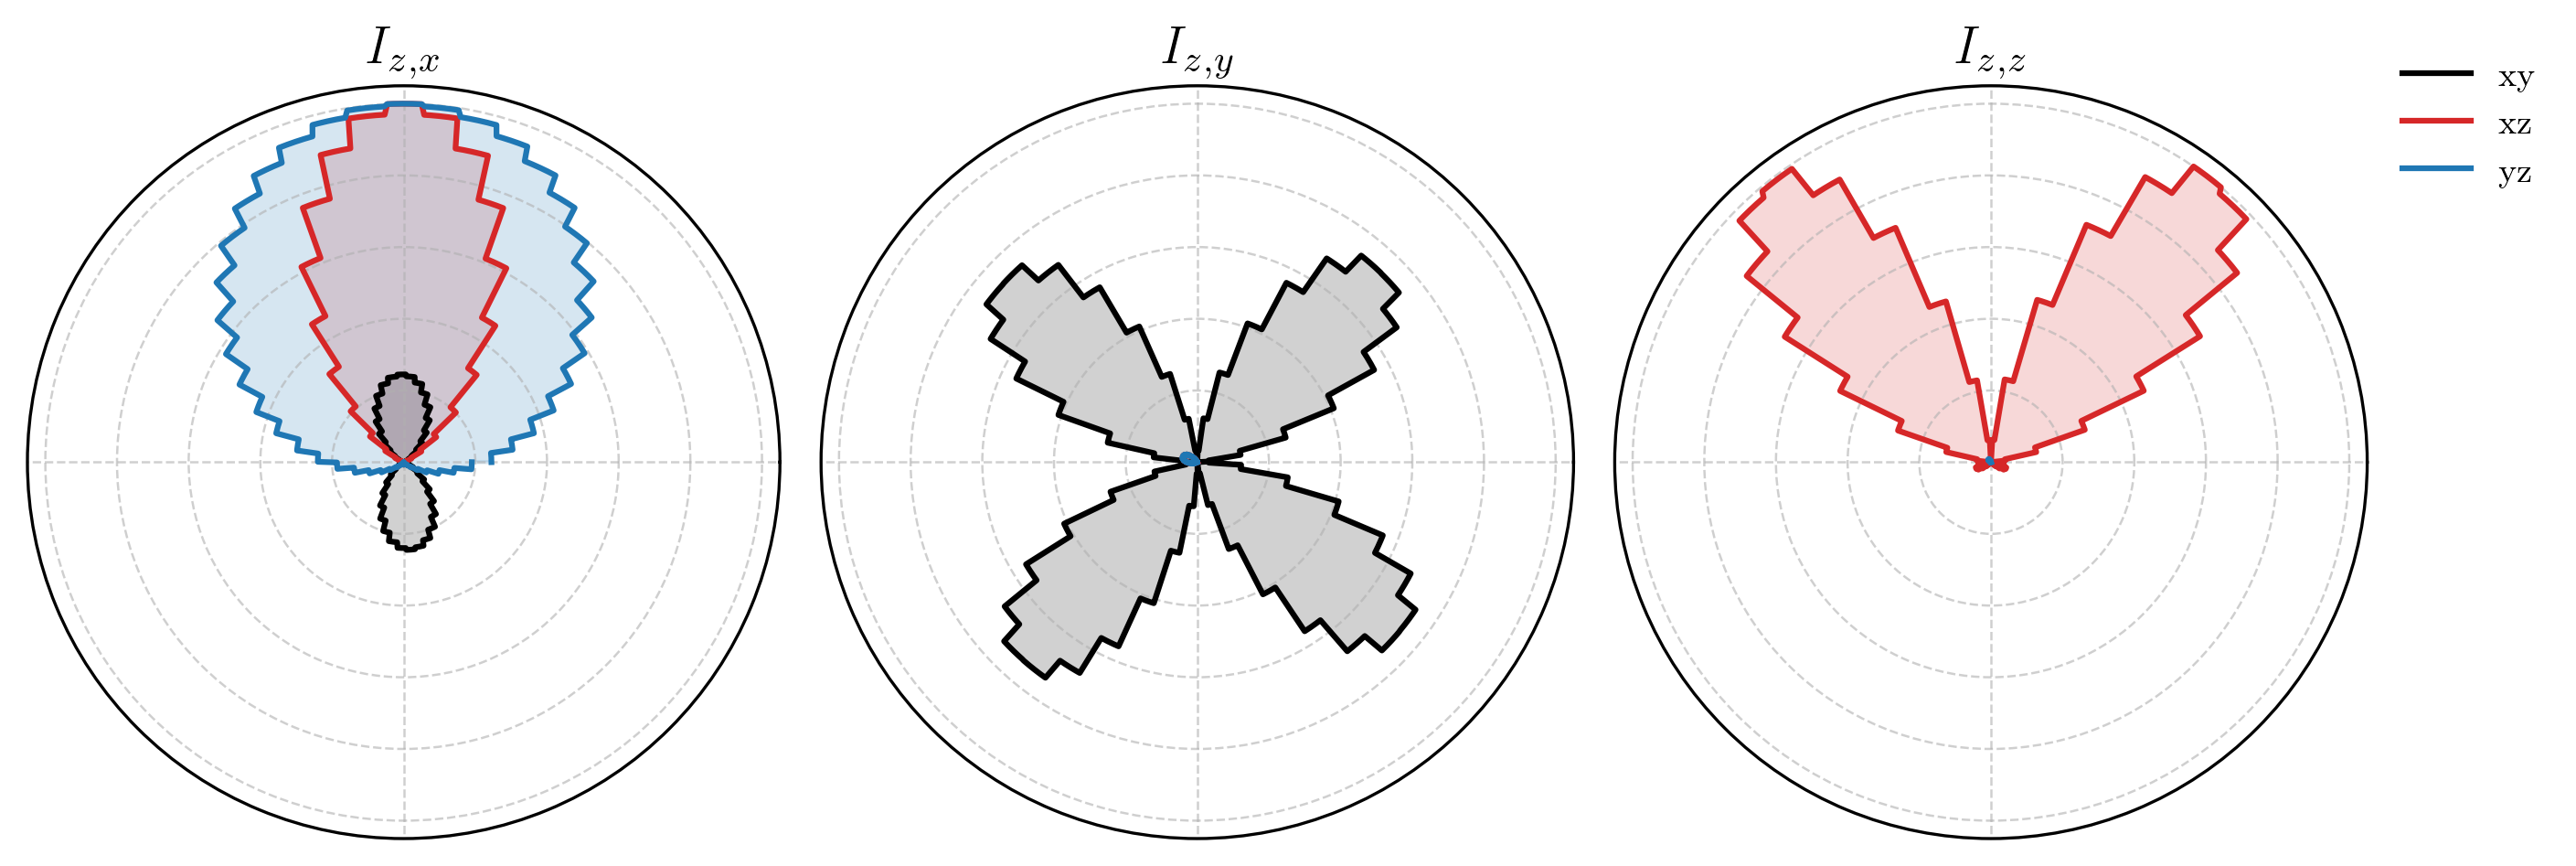

In [32]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_z_Ex, I_com_z_Ey, I_com_z_Ez], labels=["z,x", "z,y", "z,z"])

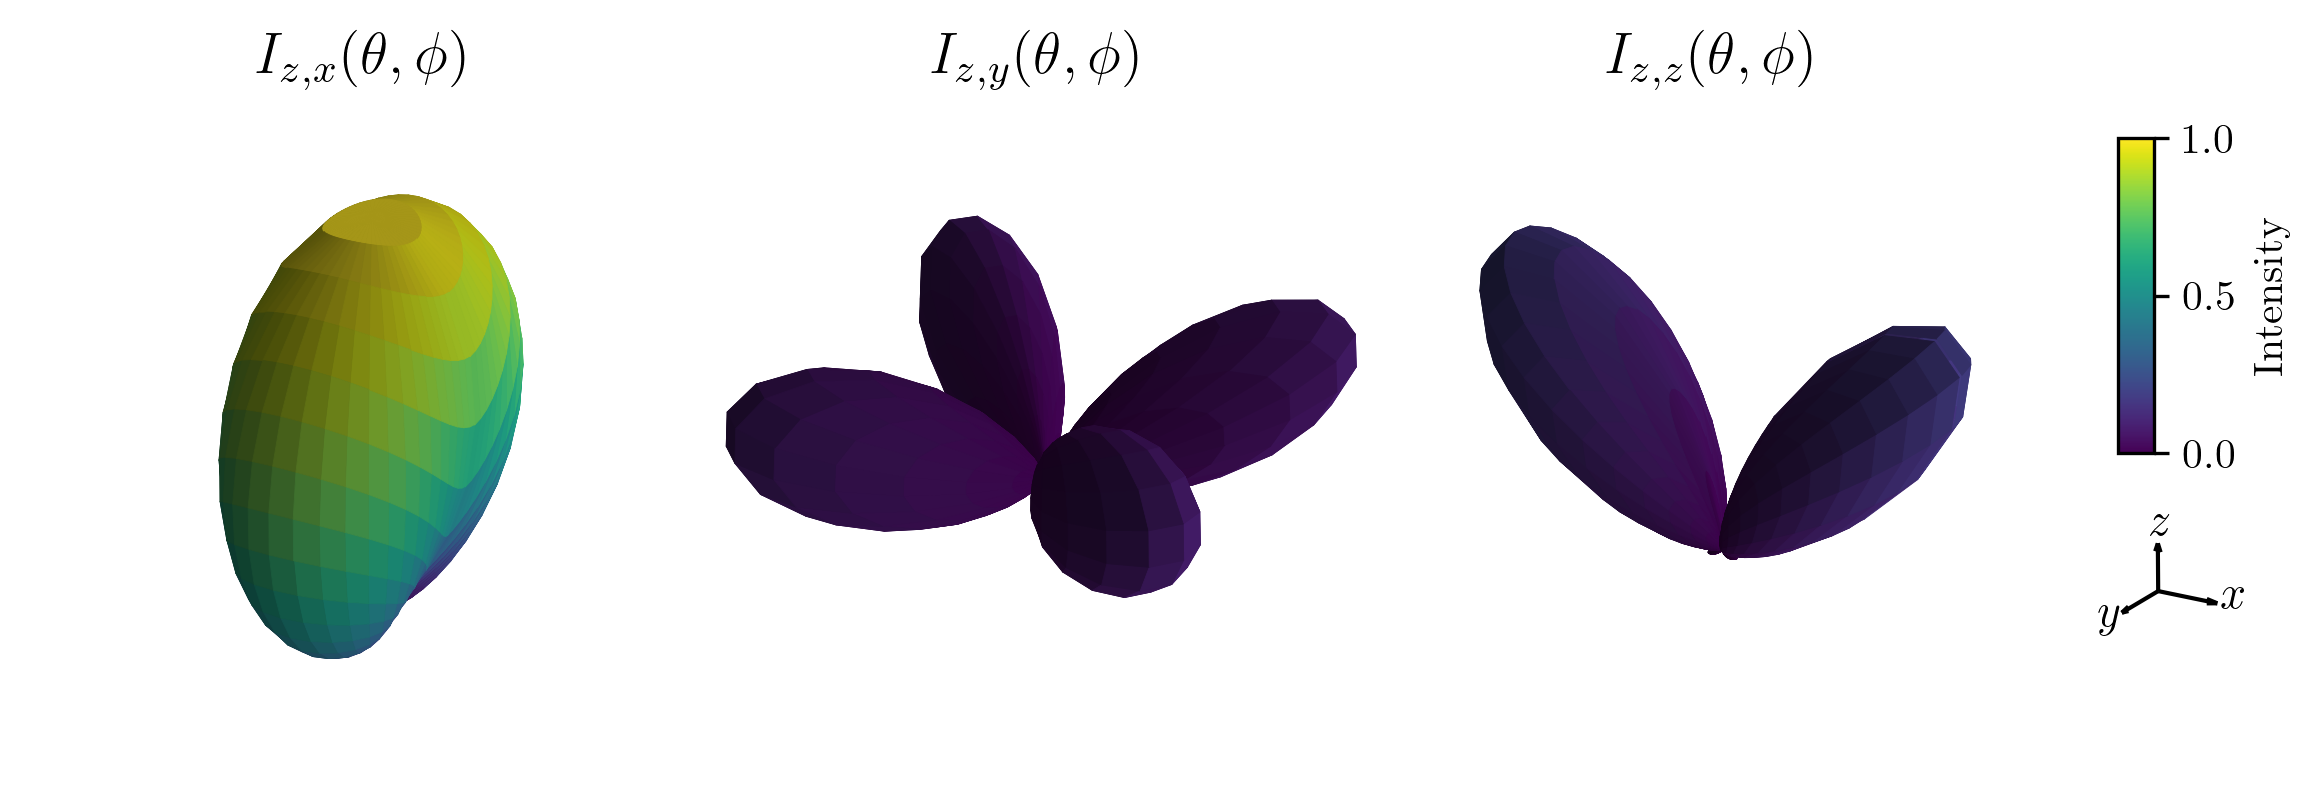

In [33]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_z_Ex, I_com_z_Ey, I_com_z_Ez], labels=["z,x", "z,y", "z,z"], scale_list=[0.38, 0.34, 0.33])

## Total COM information patterns

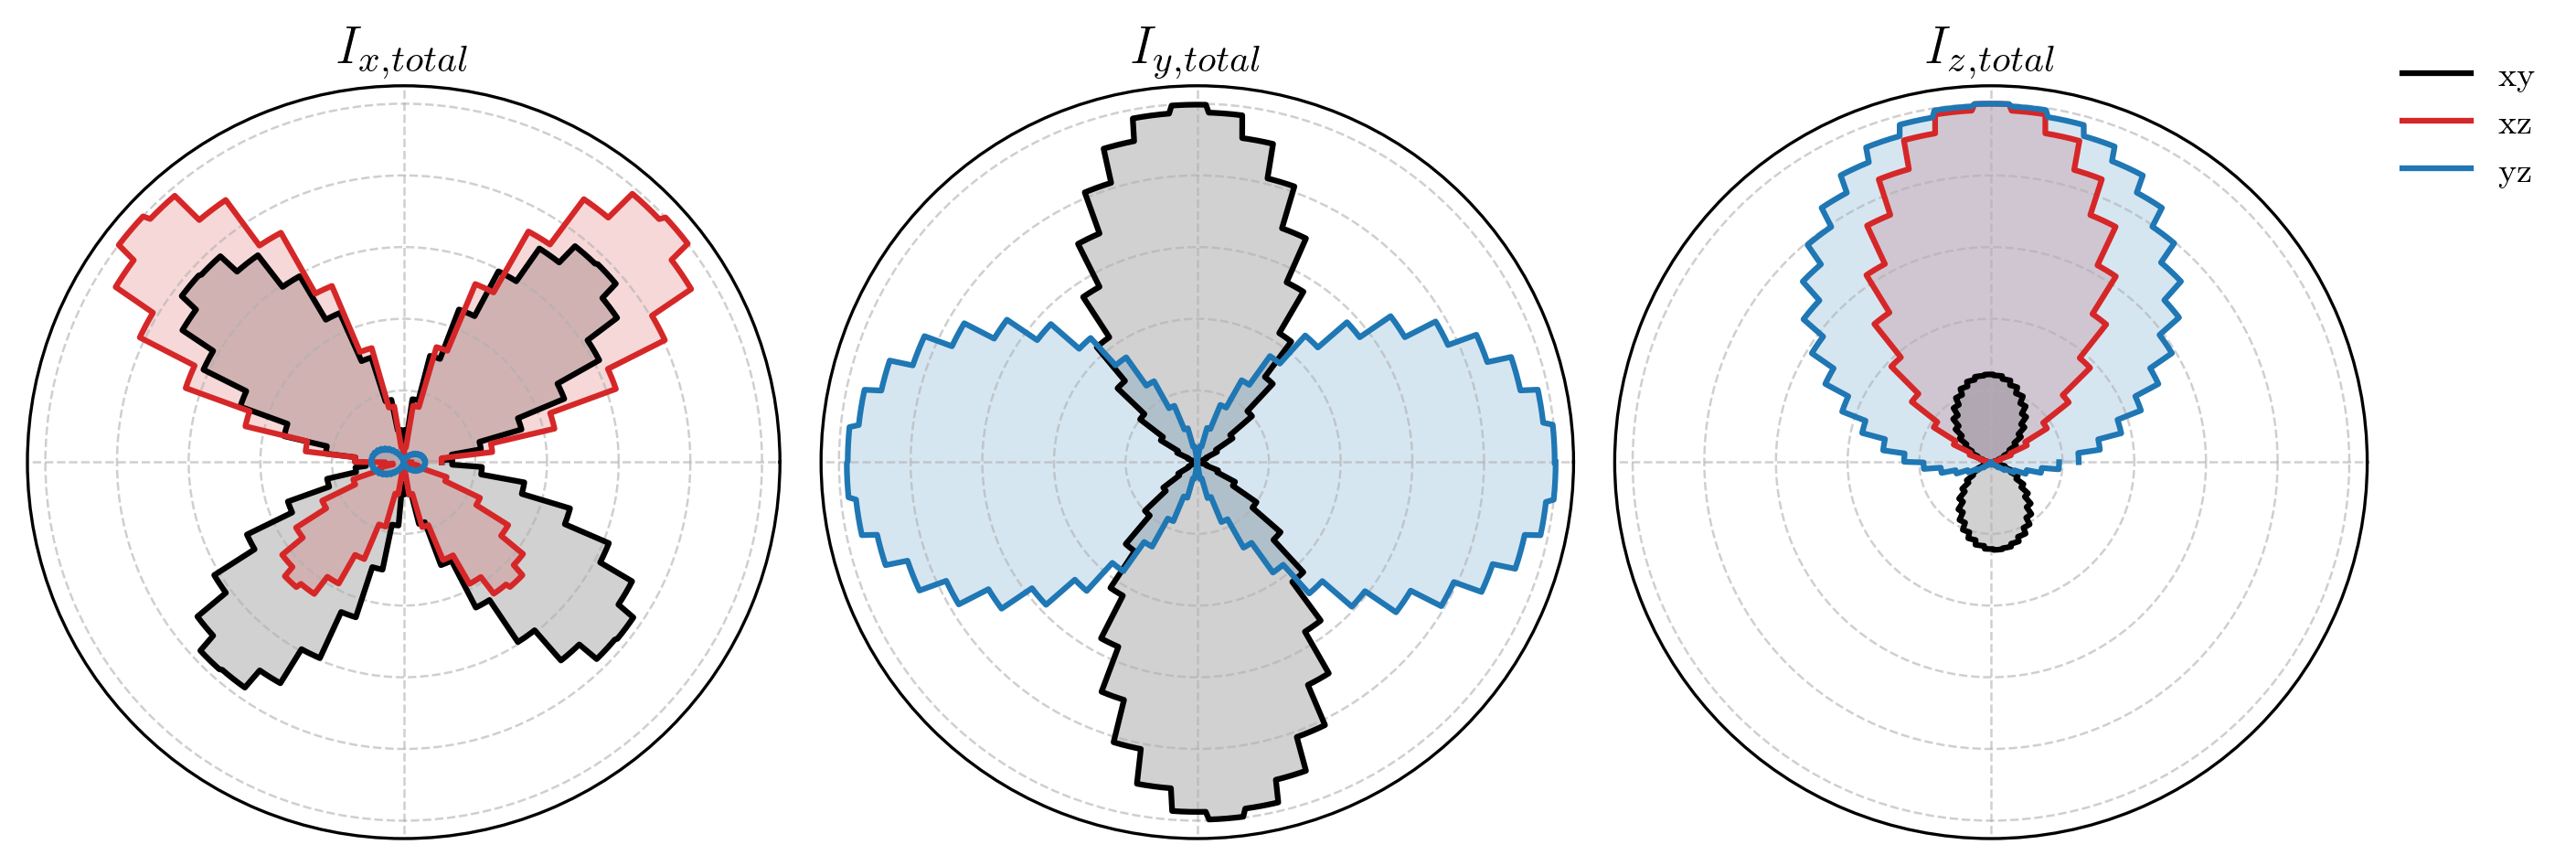

In [34]:
plots.plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_total, I_com_y_total, I_com_z_total], labels=["x,total", "y,total", "z,total"])

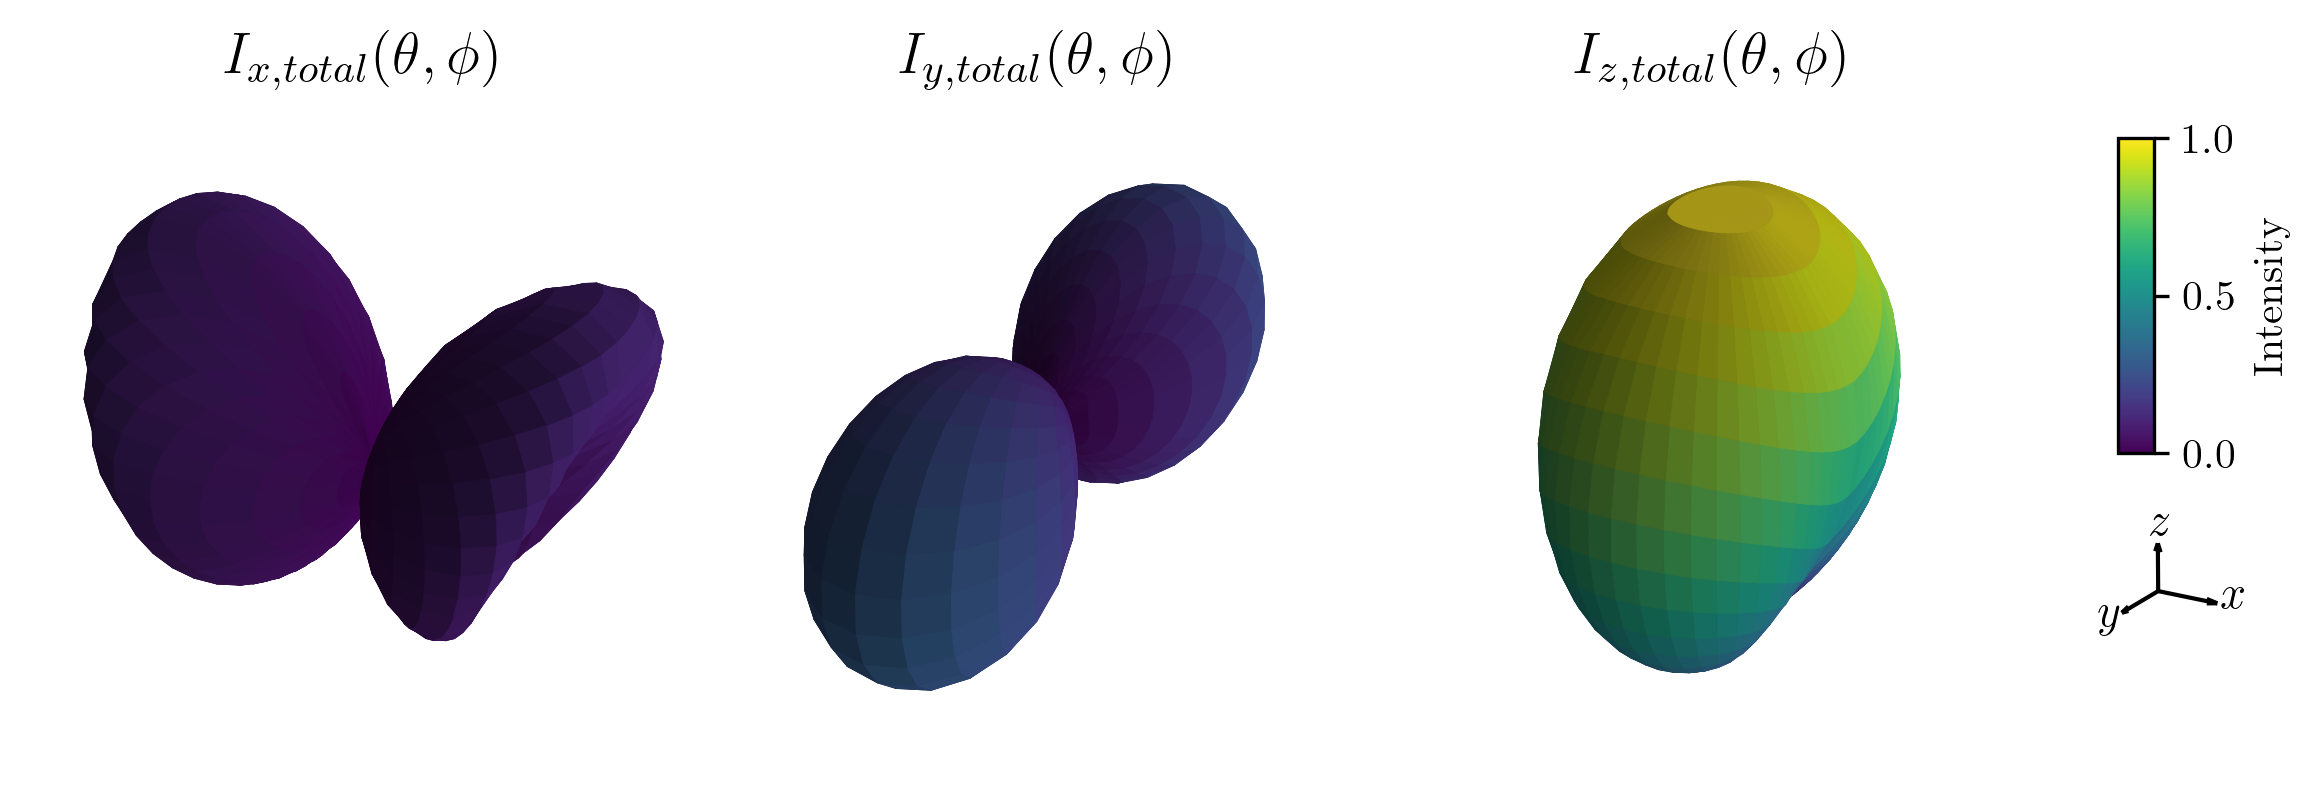

In [35]:
plots.plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_total, I_com_y_total, I_com_z_total], labels=["x,total", "y,total", "z,total"], scale_list=[0.32, 0.22, 0.36])

## Maximum detection efficiency

In [36]:
hemisphere = params.PLUS_Z_HEMISPHERE_THETA_MAX
eta_lib_x = mt.max_detection_efficiency(I_lib_x_total, Nteta, Nphi, hemisphere)
eta_lib_y = mt.max_detection_efficiency(I_lib_y_total, Nteta, Nphi, hemisphere)
eta_lib_z = mt.max_detection_efficiency(I_lib_z_total, Nteta, Nphi, hemisphere)

eta_com_x = mt.max_detection_efficiency(I_com_x_total, Nteta, Nphi, hemisphere)
eta_com_y = mt.max_detection_efficiency(I_com_y_total, Nteta, Nphi, hemisphere)
eta_com_z = mt.max_detection_efficiency(I_com_z_total, Nteta, Nphi, hemisphere)

print("Maximum detection efficiency for libration")
print(f"x: {100 * eta_lib_x:.2f} %")
print(f"y: {100 * eta_lib_y:.2f} %")
print(f"z: {100 * eta_lib_z:.2f} %")

print("\nMaximum detection efficiency for COM")
print(f"x: {100 * eta_com_x:.2f} %")
print(f"y: {100 * eta_com_y:.2f} %")
print(f"z: {100 * eta_com_z:.2f} %")

Maximum detection efficiency for libration
x: 82.44 %
y: 52.13 %
z: 49.12 %

Maximum detection efficiency for COM
x: 61.68 %
y: 49.48 %
z: 92.45 %


## Optical force vs displacement

In [37]:
Force = mt.force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=np.array([-200.0, 0.0, 200.0]), field_index=field_index)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 108.2ms, inv.: 894.0ms, repropa.: 6861.8ms (1 field configs), tot: 7864.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 98.6ms, inv.: 959.4ms, repropa.: 5823.9ms (1 field configs), tot: 6882.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 104.9ms, inv.: 1011.3ms, repropa.: 7462.8ms (1 field configs), tot: 8579.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 106.6ms, inv.: 956.2ms, repropa.: 5429.4ms (1 field configs), tot: 6492.3ms
structure initialization - automatic mesh de

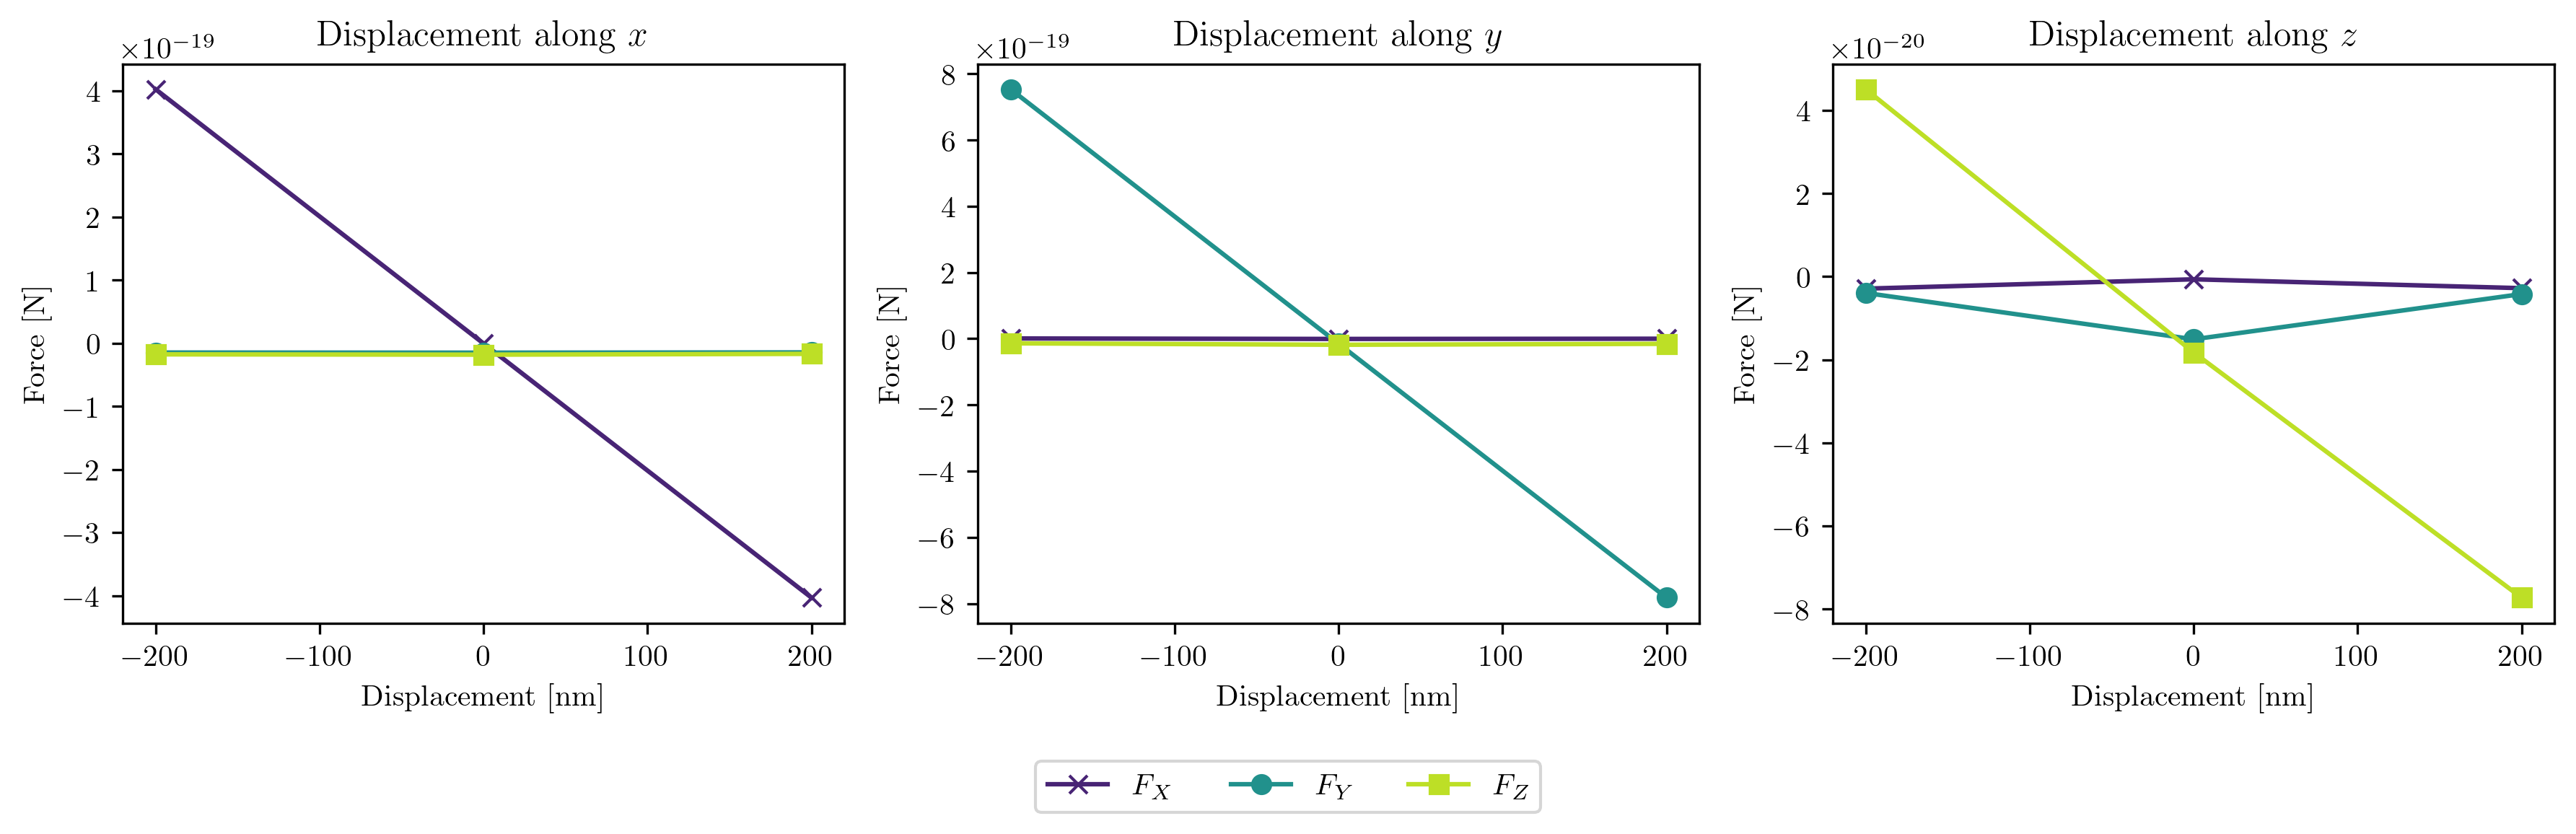

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Displacement along $x$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $y$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $z$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>],
       dtype=object))

In [38]:
plots.plot_force_displacement(displacements=np.array([-200.0, 0.0, 200.0]), Force=Force)

## Optical torque vs rotation

In [39]:
Torque = mt.torque_vs_rotation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, angles_deg= np.array([-3.0, 0.0, 3.0]), field_index=field_index)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 102.8ms, inv.: 899.0ms, repropa.: 4278.8ms (1 field configs), tot: 5280.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 101.6ms, inv.: 919.1ms, repropa.: 4676.4ms (1 field configs), tot: 5697.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 96.8ms, inv.: 954.8ms, repropa.: 4831.3ms (1 field configs), tot: 5883.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 94.8ms, inv.: 928.0ms, repropa.: 4832.5ms (1 field configs), tot: 5855.5ms
structure initialization - automatic mesh dete

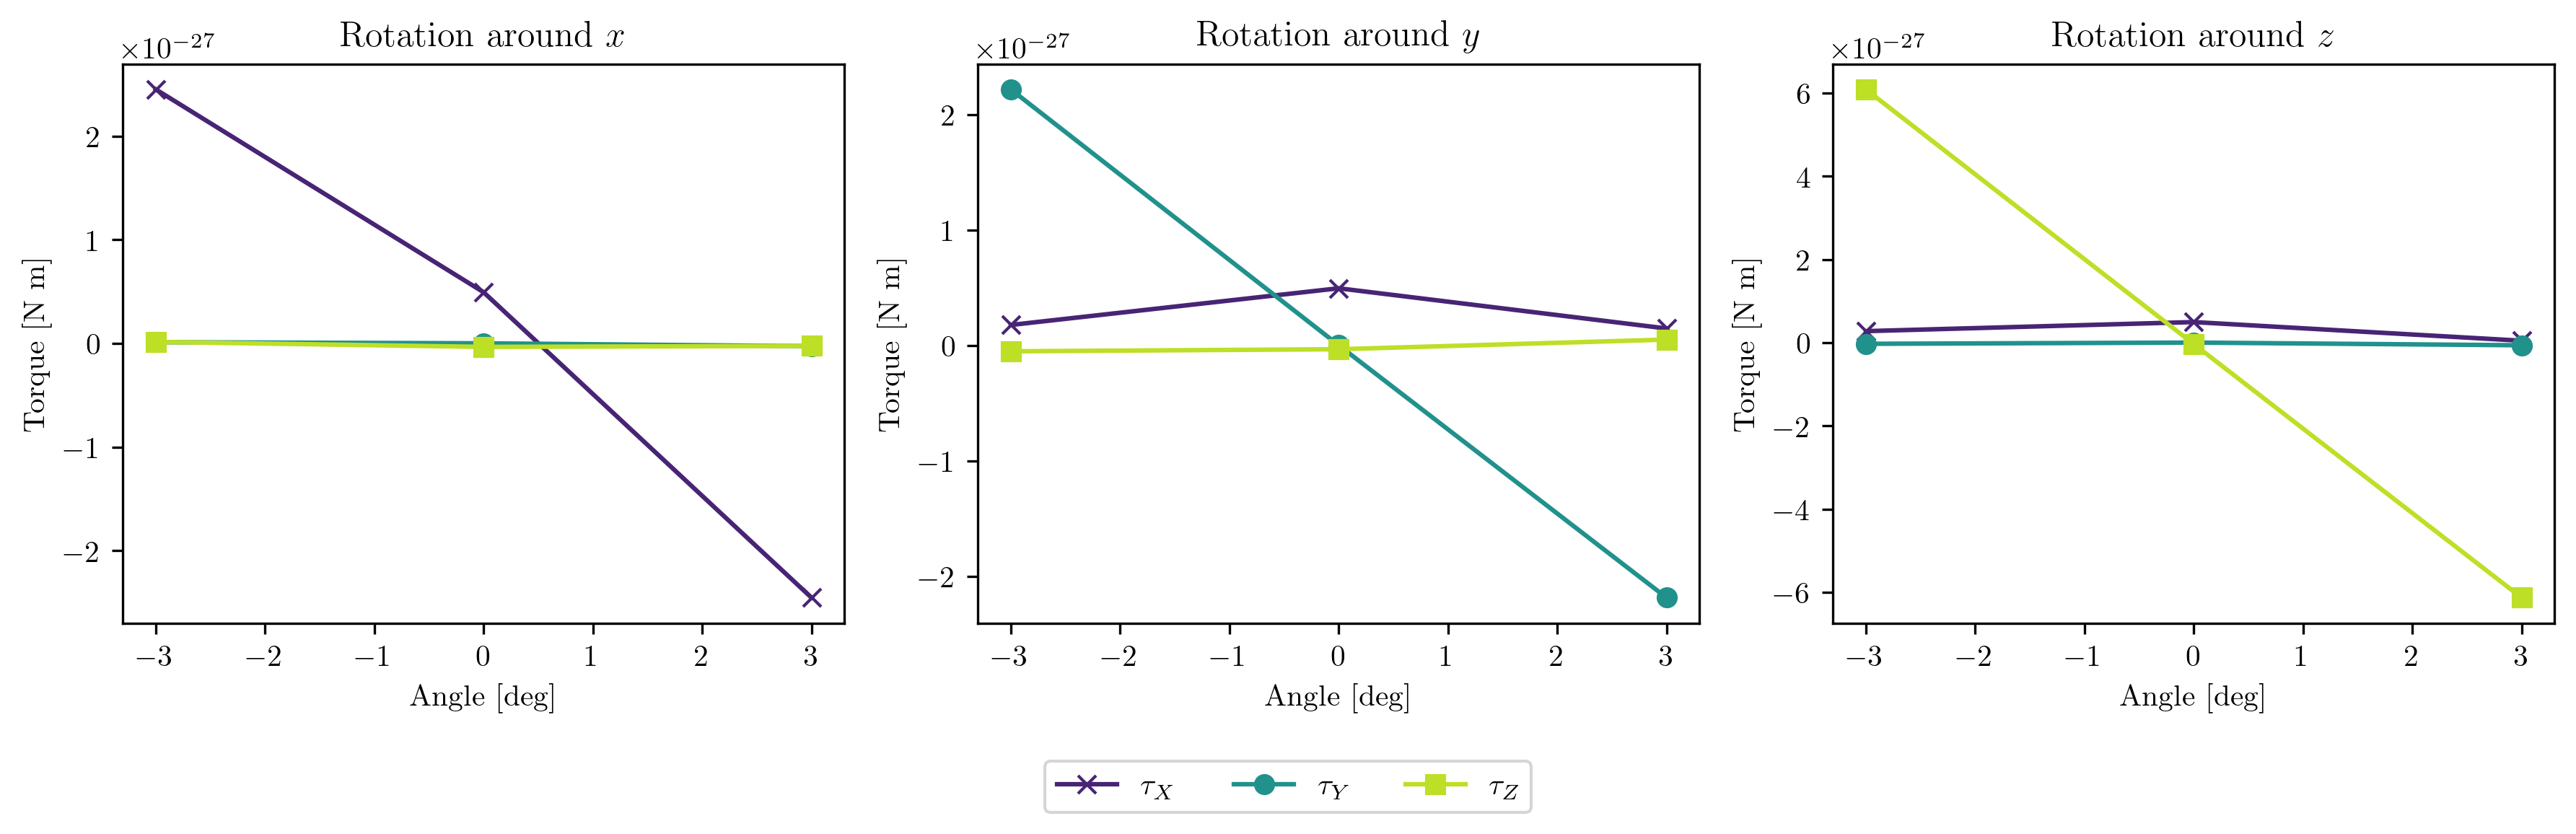

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Rotation around $x$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $y$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $z$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>],
       dtype=object))

In [40]:
plots.plot_torque_rotation(angles_deg= np.array([-3.0, 0.0, 3.0]), Torque=Torque)

## Recoil heating rate

In [41]:
recoil_displacements_nm = np.array([-200.0, 0.0, 200.0])
E_scat = lmi.scattered_farfield_from_simulation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, Nteta=Nteta, Nphi=Nphi, 
                                            field_index=field_index, r=r)
S_FF_x = mt.recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=0)
S_FF_y = mt.recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=1)
S_FF_z = mt.recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=2)

Force_recoil = mt.force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=recoil_displacements_nm, 
                                     field_index=field_index)

Omega_x, k_x = mt.trap_frequency(recoil_displacements_nm, Force_recoil["X"][:, 0], mass)
Omega_y, k_y = mt.trap_frequency(recoil_displacements_nm, Force_recoil["Y"][:, 1], mass)
Omega_z, k_z = mt.trap_frequency(recoil_displacements_nm, Force_recoil["Z"][:, 2], mass)

Gamma_x = mt.heating_rate(S_FF_x, mass, Omega_x)
Gamma_y = mt.heating_rate(S_FF_y, mass, Omega_y)
Gamma_z = mt.heating_rate(S_FF_z, mass, Omega_z)

print("Mass")
print(f"m = {mass:.6e} kg")

print("\nTrap stiffness")
print(f"k_x = {k_x:.6e} N/m")
print(f"k_y = {k_y:.6e} N/m")
print(f"k_z = {k_z:.6e} N/m")

print("\nTrap frequencies")
print(f"Omega_x = {Omega_x:.6e} rad/s, f_x = {Omega_x / (2*np.pi):.6e} Hz")
print(f"Omega_y = {Omega_y:.6e} rad/s, f_y = {Omega_y / (2*np.pi):.6e} Hz")
print(f"Omega_z = {Omega_z:.6e} rad/s, f_z = {Omega_z / (2*np.pi):.6e} Hz")

print("\nRecoil force-noise PSD")
print(f"S_FF_x = {S_FF_x:.6e}")
print(f"S_FF_y = {S_FF_y:.6e}")
print(f"S_FF_z = {S_FF_z:.6e}")

print("\nRecoil heating rates")
print(f"Gamma_x = {Gamma_x:.6e} phonons/s")
print(f"Gamma_y = {Gamma_y:.6e} phonons/s")
print(f"Gamma_z = {Gamma_z:.6e} phonons/s")

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 99.8ms, inv.: 926.8ms, repropa.: 4594.5ms (1 field configs), tot: 5621.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 121.0ms, inv.: 992.9ms, repropa.: 4540.1ms (1 field configs), tot: 5654.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 108.8ms, inv.: 1000.5ms, repropa.: 4409.0ms (1 field configs), tot: 5518.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 102.3ms, inv.: 981.2ms, repropa.: 4536.8ms (1 field configs), tot: 5620.4ms
structure initialization - automatic mesh de